---
## Statistical Analysis 
---

### About this notebook 
This notebook applies formal hypothesis tests to the four most
business-critical patterns identified in Notebook 01 and reports
findings with test statistics, p-values, effect sizes, and plain
English business interpretations.

**Statistical reporting standard for every test:**
1. Test statistic - the numerical output of the test
2. P-value - probability this result occurred by chance
3. Effect size - how large the difference actually is
4. Plain English - what it means for the business

**Why all four, not just p-value:**
A p-value tells you whether a difference is real.
An effect size tells you whether it matters.
A finding that is statistically significant with a negligible
effect size is real but practically useless to a business.
Both numbers together tell the complete story.

**Hypotheses tested in this notebook:**
1. Late delivery is associated with significantly lower review scores
2. High-value RFM customers behave statistically differently
3. Review scores vary significantly by product category
4. Seasonal revenue patterns are statistically significant

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings 
import os

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']    = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.titleweight']  = 'bold'

COLOUR_PRIMARY   = '#1B3A5C'
COLOUR_ACCENT    = '#2E75B6'
COLOUR_HIGHLIGHT = '#E74C3C'
COLOUR_NEUTRAL   = '#95A5A6'
COLOUR_GREEN     = '#2ECC71'
COLOUR_EMPHASIS  = '#d00000'

os.makedirs('../outputs/figures', exist_ok=True)




In [2]:
#loading the data 

master = pd.read_csv(
    '../data/processed/master.csv',
    parse_dates=[
        'order_purchase_timestamp',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
        'order_approved_at'
    ]
)

rfm_base = pd.read_csv(
    '../data/processed/rfm_base.csv',
    parse_dates=['first_order', 'last_order']
)

In [3]:
print(f"master:   {master.shape[0]:,} rows x {master.shape[1]} columns")
print(f"rfm_base: {rfm_base.shape[0]:,} rows x {rfm_base.shape[1]} columns")
print("\nReady.")

master:   113,425 rows x 29 columns
rfm_base: 96,136 rows x 10 columns

Ready.


---
## Hypothesis One 
---

**Null hypothesis (H₀):**
There is no difference in review scores between orders that
arrived late and orders that arrived on time or early.
 
**Alternative hypothesis (H₁):**
Orders that arrived late have significantly lower review scores
than orders that arrived on time or early.

### The Decision Rule
If p-value < 0.05: reject H₀ — the difference is real.
If p-value ≥ 0.05: fail to reject H₀ — cannot confirm the difference.


In [4]:
master['order_status'].head(15)

0     delivered
1     delivered
2     delivered
3     delivered
4     delivered
5     delivered
6      invoiced
7     delivered
8     delivered
9     delivered
10    delivered
11    delivered
12    delivered
13    delivered
14    delivered
Name: order_status, dtype: str

In [5]:
delivered = master[master['order_status'] == 'delivered'].copy()

delivered_orders = delivered.drop_duplicates(subset='order_id').copy()

reviewed_delivered = delivered_orders.dropna(subset=['review_score']).copy()

In [6]:
on_time_scores = reviewed_delivered[
    reviewed_delivered['was_late'] == False
]['review_score']

late_scores = reviewed_delivered[
    reviewed_delivered['was_late'] == True
]['review_score']



In [7]:
print("Group sizes:")
print(f"  On-time / early orders: {len(on_time_scores):,}")
print(f"  Late orders:            {len(late_scores):,}")
print(f"  Total reviewed:         {len(reviewed_delivered):,}")
 
print("\nGroup statistics:")
print(f"  On-time mean score: {on_time_scores.mean():.2f}")
print(f"  Late mean score:    {late_scores.mean():.2f}")
print(f"  Raw difference:     {on_time_scores.mean() - late_scores.mean():.2f} points")
print(f"  On-time median:     {on_time_scores.median():.1f}")
print(f"  Late median:        {late_scores.median():.1f}")

Group sizes:
  On-time / early orders: 89,451
  Late orders:            6,381
  Total reviewed:         95,832

Group statistics:
  On-time mean score: 4.29
  Late mean score:    2.27
  Raw difference:     2.02 points
  On-time median:     5.0
  Late median:        1.0


In [8]:
print("\nOn-time score distribution (%):")
print((on_time_scores.value_counts(normalize=True).sort_index() * 100).round(1))
print("\nLate score distribution (%):")
print((late_scores.value_counts(normalize=True).sort_index() * 100).round(1))


On-time score distribution (%):
review_score
1.0     6.6
2.0     2.6
3.0     8.1
4.0    20.4
5.0    62.3
Name: proportion, dtype: float64

Late score distribution (%):
review_score
1.0    53.8
2.0     8.6
3.0    10.9
4.0    10.2
5.0    16.5
Name: proportion, dtype: float64


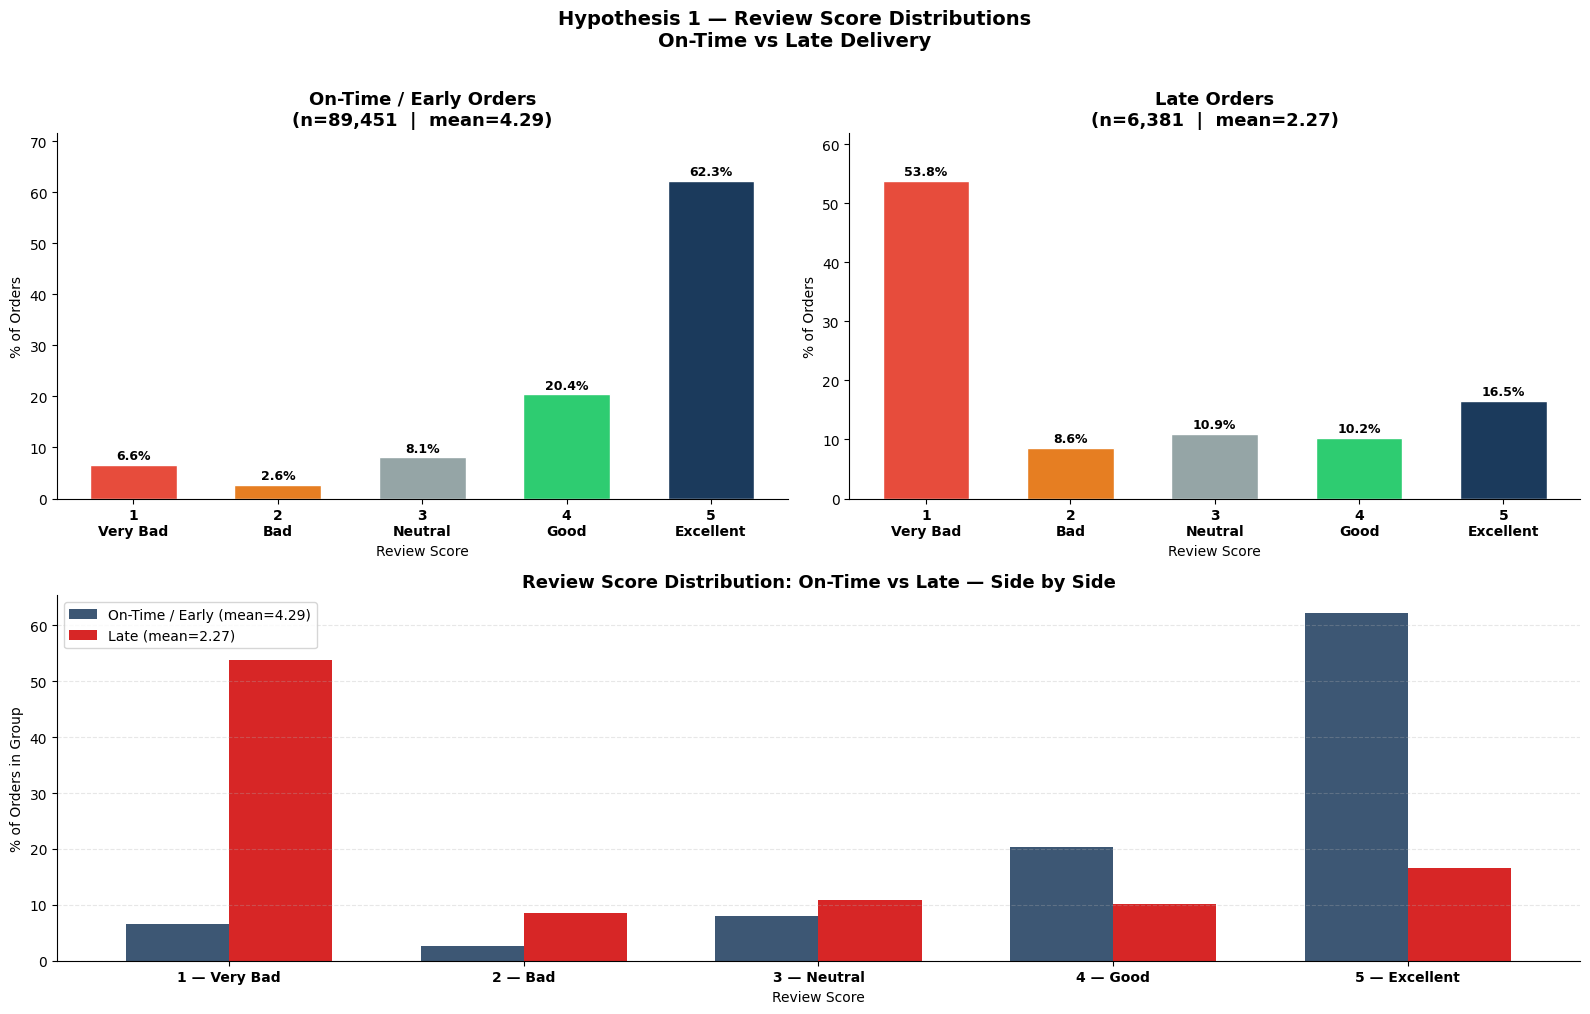

Chart saved.


In [9]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig)
 
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])
 
score_colours = {
    1: '#E74C3C',
    2: '#E67E22',
    3: '#95A5A6',
    4: '#2ECC71',
    5: '#1B3A5C'
}
 
# ── Panel 1: On-time distribution ─────────────────────────
on_time_pct = on_time_scores.value_counts(normalize=True).sort_index() * 100
 
bars1 = ax1.bar(
    on_time_pct.index,
    on_time_pct.values,
    color=[score_colours[s] for s in on_time_pct.index],
    edgecolor='white',
    width=0.6
)
for bar, val in zip(bars1, on_time_pct.values):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
ax1.set_title(
    f'On-Time / Early Orders\n(n={len(on_time_scores):,}  |  mean={on_time_scores.mean():.2f})',
    fontweight='bold'
)
ax1.set_xlabel('Review Score')
ax1.set_ylabel('% of Orders')
ax1.set_xticks([1,2,3,4,5])
ax1.set_xticklabels(['1\nVery Bad','2\nBad','3\nNeutral','4\nGood','5\nExcellent'], fontweight='semibold')
ax1.set_ylim(0, on_time_pct.max() * 1.15)
 
# ── Panel 2: Late distribution ─────────────────────────────
late_pct = late_scores.value_counts(normalize=True).sort_index() * 100
 
bars2 = ax2.bar(
    late_pct.index,
    late_pct.values,
    color=[score_colours[s] for s in late_pct.index],
    edgecolor='white',
    width=0.6
)
for bar, val in zip(bars2, late_pct.values):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
ax2.set_title(
    f'Late Orders\n(n={len(late_scores):,}  |  mean={late_scores.mean():.2f})',
    fontweight='bold'
)
ax2.set_xlabel('Review Score')
ax2.set_ylabel('% of Orders')
ax2.set_xticks([1,2,3,4,5])
ax2.set_xticklabels(['1\nVery Bad','2\nBad','3\nNeutral','4\nGood','5\nExcellent'], fontweight='semibold')
ax2.set_ylim(0, late_pct.max() * 1.15)
all_scores = pd.DataFrame({
    'On-Time / Early': on_time_pct,
    'Late':            late_pct
}).fillna(0)
 
x     = np.arange(1, 6)
width = 0.35

# ── Panel 3: Review Score Distribution: On-Time vs Late — Side by Side ─────────────────────────────
bars3a = ax3.bar(
    x - width/2,
    all_scores['On-Time / Early'],
    width=width,
    color=COLOUR_PRIMARY,
    alpha=0.85,
    label=f'On-Time / Early (mean={on_time_scores.mean():.2f})'
)
bars3b = ax3.bar(
    x + width/2,
    all_scores['Late'],
    width=width,
    color=COLOUR_EMPHASIS,
    alpha=0.85,
    label=f'Late (mean={late_scores.mean():.2f})'
)
 
ax3.set_xlabel('Review Score')
ax3.set_ylabel('% of Orders in Group')
ax3.set_title(
    'Review Score Distribution: On-Time vs Late — Side by Side',
    fontweight='bold'
)
ax3.set_xticks(x)
ax3.set_xticklabels(['1 — Very Bad','2 — Bad','3 — Neutral','4 — Good','5 — Excellent'], fontweight='semibold')
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
 
plt.suptitle(
    'Hypothesis 1 — Review Score Distributions\nOn-Time vs Late Delivery',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    '../outputs/figures/h1_score_distributions.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

In [10]:
stat, p_value = stats.mannwhitneyu (
    on_time_scores, 
    late_scores,
    alternative= 'greater'
)

n1 = len(on_time_scores)
n2 = len(late_scores)

effect_size_r = 1 - (2 * stat) / (n1 * n2)

if abs(effect_size_r) >= 0.5:
    magnitude = 'large'
elif abs(effect_size_r) >= 0.3:
    magnitude = 'medium'
elif abs(effect_size_r) >= 0.1:
    magnitude = 'small'
else: magnitude = 'negligible'

significant = p_value < 0.05



In [11]:
print("=" * 55)
print("  HYPOTHESIS 1 — TEST RESULTS")
print("=" * 55)
print()
print(f"  Test:                Mann-Whitney U")
print(f"  U statistic:         {stat:,.0f}")
print(f"  P-value:             {p_value:.6f}")
print(f"  Significant:         {'YES  ✓' if significant else 'NO  ✗'} (threshold: 0.05)")
print()
print(f"  Effect size (r):     {effect_size_r:.4f}")
print(f"  Magnitude:           {magnitude}")
print()
print(f"  On-time mean:        {on_time_scores.mean():.3f}")
print(f"  Late mean:           {late_scores.mean():.3f}")
print(f"  Difference:          {on_time_scores.mean() - late_scores.mean():.3f} points")
print()
if significant:
    print(f"  CONCLUSION: Reject H₀")
    print(f"  Late deliveries produce significantly lower review scores.")
else:
    print(f"  CONCLUSION: Fail to reject H₀")
    print(f"  Cannot confirm a significant difference.")

  HYPOTHESIS 1 — TEST RESULTS

  Test:                Mann-Whitney U
  U statistic:         467,414,644
  P-value:             0.000000
  Significant:         YES  ✓ (threshold: 0.05)

  Effect size (r):     -0.6378
  Magnitude:           large

  On-time mean:        4.290
  Late mean:           2.271
  Difference:          2.019 points

  CONCLUSION: Reject H₀
  Late deliveries produce significantly lower review scores.


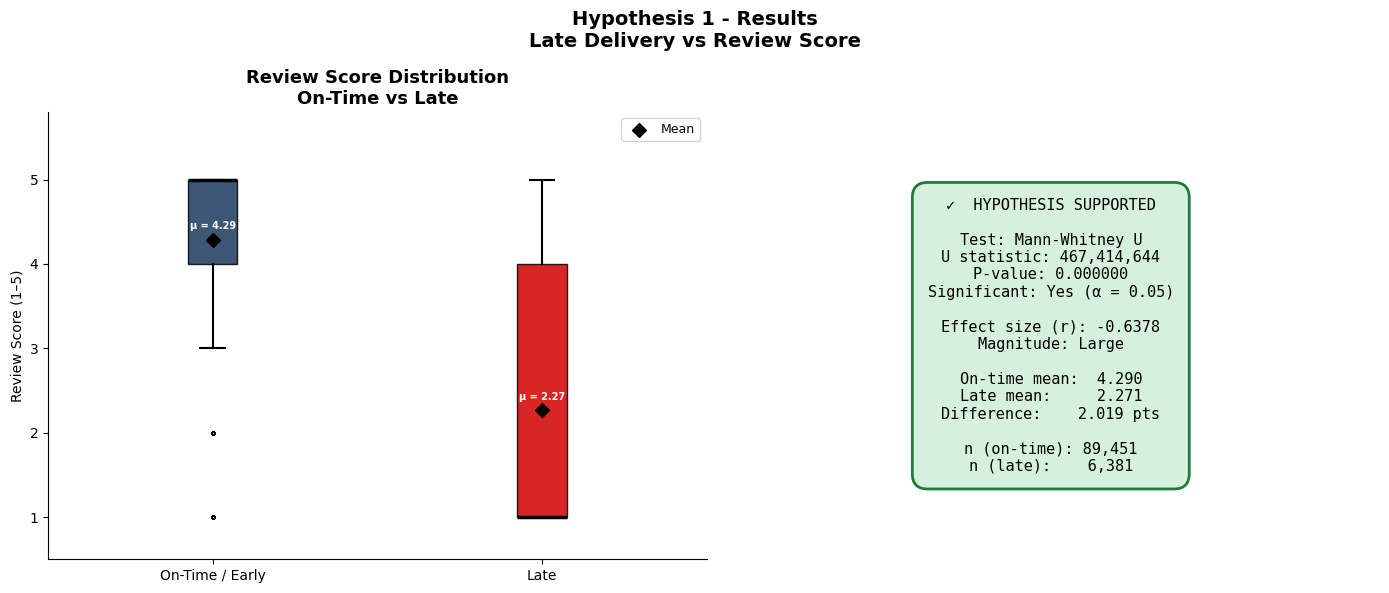

Chart saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bp = axes[0].boxplot(
    [on_time_scores, late_scores],
    labels=['On-Time / Early', 'Late'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
 
bp['boxes'][0].set_facecolor(COLOUR_PRIMARY)
bp['boxes'][1].set_facecolor(COLOUR_EMPHASIS)
for patch in bp['boxes']:
    patch.set_alpha(0.85)
 

axes[0].scatter(
    [1, 2],
    [on_time_scores.mean(), late_scores.mean()],
    marker='D', color='black', s=50, zorder=5, label='Mean'
)
 
# Mean value annotations
axes[0].text(
    1, on_time_scores.mean() + 0.12,
    f'μ = {on_time_scores.mean():.2f}',
    ha='center', fontsize=7,
    color='white', fontweight='bold'
)
axes[0].text(
    2, late_scores.mean() + 0.12,
    f'μ = {late_scores.mean():.2f}',
    ha='center', fontsize=7,
    color='white', fontweight='bold'
)
 
axes[0].set_ylabel('Review Score (1–5)')
axes[0].set_ylim(0.5, 5.8)
axes[0].set_title(
    'Review Score Distribution\nOn-Time vs Late',
    fontweight='bold'
)
axes[0].legend(fontsize=9)
 
# ── Panel 2: Test result summary card ─────────────────────
axes[1].axis('off')
 
result_color  = '#D5F0DC' if significant else '#FAD7D3'
border_color  = '#217A3C' if significant else '#C0392B'
result_label  = 'HYPOTHESIS SUPPORTED' if significant else 'HYPOTHESIS NOT SUPPORTED'
result_symbol = '✓' if significant else '✗'
summary_text = (
    f"{result_symbol}  {result_label}\n\n"
    f"Test: Mann-Whitney U\n"
    f"U statistic: {stat:,.0f}\n"
    f"P-value: {p_value:.6f}\n"
    f"Significant: {'Yes' if significant else 'No'} (α = 0.05)\n\n"
    f"Effect size (r): {effect_size_r:.4f}\n"
    f"Magnitude: {magnitude.capitalize()}\n\n"
    f"On-time mean:  {on_time_scores.mean():.3f}\n"
    f"Late mean:     {late_scores.mean():.3f}\n"
    f"Difference:    {on_time_scores.mean() - late_scores.mean():.3f} pts\n\n"
    f"n (on-time): {n1:,}\n"
    f"n (late):    {n2:,}"
)
 
axes[1].text(
    0.5, 0.5,
    summary_text,
    ha='center', va='center',
    fontsize=11,
    fontfamily='monospace',
    transform=axes[1].transAxes,
    bbox=dict(
        boxstyle='round,pad=1',
        facecolor=result_color,
        edgecolor=border_color,
        linewidth=2
    )
)
 
plt.suptitle(
    'Hypothesis 1 - Results\nLate Delivery vs Review Score',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../outputs/figures/h1_test_results.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

---
# Hypothesis 1 - Finding Card
---
### **Claim Tested**: Late deliveries produce significantly lower review scores than on-time or early deliveries.


**Result:** SUPPORTED 

**Evidence:**
 
| Metric | Value |
|--------|-------|
| On-time mean score | 4.29 |
| Late mean score | 2.27 |
| Raw difference | 2.02 points |
| Mann-Whitney U | 467 414 644 |
| P-value | 0.000000 |
| Significant (p < 0.05) | Yes  |
| Effect size (r) | -0.638 |
| Magnitude |  Large |
| n (on-time) | 89 451 |
| n (late) | 6 381 |

Late deliveries receive review scores that are 2.02 points
lower on average than on-time deliveries (4.29 vs 2.27).
This difference is statistically significant (p < 0.001),
meaning it is extremely unlikely to have occurred by chance.
The effect size of -0.638 indicates a large
practical difference , the gap is not just statistically
real, it is large enough to matter operationally.

Delivery delay and satisfaction were found to be somewhat correlated (r = −0.27) in Notebook 01.
This test now verifies the existence of the link, and that delivery is one, but not the only, factor that influences satisfaction; effect size contextualizes it.
### **Business Implication**

Every percentage point reduction in the late delivery rate
(currently 6.8%) has a measurable, statistically confirmed
impact on platform satisfaction scores. Given that
satisfaction drives repeat purchase probability, improving
delivery reliability is one of the highest-return operational
investments available.
 
However, the large effect size also signals that
addressing delivery alone will not transform the satisfaction
picture. Non-delivery drivers such as product quality, seller
responsiveness, product description accuracy ,  also need
attention (investigated in Hypothesis 3).

---
---

---
## Hypothesis Two
---

**Null hypothesis (H₀):**
High-value RFM customers (top 20% by composite score) show
no statistically significant difference in purchasing behaviour
from low-value customers (bottom 20%) across basket size,
frequency, category diversity, and payment method.
 
**Alternative hypothesis (H₁):**
High-value RFM customers behave statistically differently
from low-value customers on at least one behavioural dimension.

In Notebook 01 (Analysis 5) we built RFM segments and observed
that Champions and Loyal Customers generate disproportionate
revenue relative to their size. But observation alone does not
prove the segments are capturing genuinely different customer
behaviours , they might just be the same type of customer who
happened to spend more by chance.

### Why Multiple Tests?
We are comparing four different variables across two groups.
Each variable requires its own test because they are different
types of data:
 
- avg_basket_value → continuous, likely skewed → Mann-Whitney U
- total_orders     → continuous, likely skewed → Mann-Whitney U
- category_diversity → continuous, likely skewed → Mann-Whitney U
- payment_type     → categorical → Chi-squared

### The Decision Rule
If p-value < 0.05 for a variable: that dimension shows a real
difference between high and low RFM customers.
Effect size tells us how large the difference is in practice.

In [13]:
try:
    rfm = pd.read_csv('../data/processed/rfm_scored.csv',
                      parse_dates=['first_order', 'last_order'])
    print("Loaded rfm_scored.csv")
except FileNotFoundError:
    rfm = rfm_base.copy()
    print("rfm_scored.csv not found — using rfm_base.csv")
    print("RFM scores will be calculated fresh.")
 
# If RFM_score column does not exist, build it
if 'RFM_score' not in rfm.columns:
    rfm['R_score'] = pd.qcut(rfm['recency_days'], q=5,
                              labels=[5,4,3,2,1], duplicates='drop').astype(int)
    rfm['F_score'] = pd.qcut(rfm['total_orders'].rank(method='first'),
                              q=5, labels=[1,2,3,4,5]).astype(int)
    rfm['M_score'] = pd.qcut(rfm['total_spend'], q=5,
                              labels=[1,2,3,4,5], duplicates='drop').astype(int)
    rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']
    print("RFM scores calculated.")

# was written because i couldnt see if my laptop saved the rfm_scored.

Loaded rfm_scored.csv


In [14]:
rfm['rfm_quintile'] = pd.qcut(
    rfm['RFM_score'],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'
)

In [15]:
high_rfm = rfm[rfm['rfm_quintile'] == 5].copy()
low_rfm  = rfm[rfm['rfm_quintile'] == 1].copy()
 
print(f"\nGroup sizes:")
print(f"  High RFM (top 20%):    {len(high_rfm):,} customers")
print(f"  Low RFM (bottom 20%):  {len(low_rfm):,} customers")
print(f"  Total customers:       {len(rfm):,}")
 
print(f"\nHigh RFM profile:")
print(f"  Mean RFM score:        {high_rfm['RFM_score'].mean():.1f}")
print(f"  Mean recency (days):   {high_rfm['recency_days'].mean():.0f}")
print(f"  Mean total orders:     {high_rfm['total_orders'].mean():.2f}")
print(f"  Mean total spend:      R${high_rfm['total_spend'].mean():.2f}")
 
print(f"\nLow RFM profile:")
print(f"  Mean RFM score:        {low_rfm['RFM_score'].mean():.1f}")
print(f"  Mean recency (days):   {low_rfm['recency_days'].mean():.0f}")
print(f"  Mean total orders:     {low_rfm['total_orders'].mean():.2f}")
print(f"  Mean total spend:      R${low_rfm['total_spend'].mean():.2f}")


Group sizes:
  High RFM (top 20%):    15,969 customers
  Low RFM (bottom 20%):  27,269 customers
  Total customers:       96,136

High RFM profile:
  Mean RFM score:        12.8
  Mean recency (days):   166
  Mean total orders:     1.15
  Mean total spend:      R$299.88

Low RFM profile:
  Mean RFM score:        6.0
  Mean recency (days):   396
  Mean total orders:     1.00
  Mean total spend:      R$81.54


In [16]:
category_diversity = (
    master
    .groupby('customer_unique_id')['product_category_name_english']
    .nunique()
    .reset_index()
    .rename(columns={'product_category_name_english': 'category_diversity'})
)

In [17]:
rfm = rfm.merge(category_diversity, on='customer_unique_id', how='left')
rfm['category_diversity'] = rfm['category_diversity'].fillna(1)
 
# Rebuild groups with the new column
high_rfm = rfm[rfm['rfm_quintile'] == 5].copy()
low_rfm  = rfm[rfm['rfm_quintile'] == 1].copy()
 
print(f"Category diversity added.")
print(f"  High RFM mean category diversity: {high_rfm['category_diversity'].mean():.2f}")
print(f"  Low RFM mean category diversity:  {low_rfm['category_diversity'].mean():.2f}")

Category diversity added.
  High RFM mean category diversity: 1.09
  Low RFM mean category diversity:  0.99


In [18]:
payment_by_customer = (
    master
    .drop_duplicates(subset='order_id')
    .groupby('customer_unique_id')['payment_type']
    .apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index(name='primary_payment_type')
   ## .rename(columns={'payment_type': 'primary_payment_type'})
)
 
rfm = rfm.merge(payment_by_customer, on='customer_unique_id', how='left')
 
high_rfm = rfm[rfm['rfm_quintile'] == 5].copy()
low_rfm  = rfm[rfm['rfm_quintile'] == 1].copy()
 
print("Payment type added.")
print(f"\nHigh RFM payment distribution:")
print(high_rfm['primary_payment_type'].value_counts(normalize=True).mul(100).round(1))
print(f"\nLow RFM payment distribution:")
print(low_rfm['primary_payment_type'].value_counts(normalize=True).mul(100).round(1))
 

Payment type added.

High RFM payment distribution:
primary_payment_type
credit_card    79.7
boleto         17.0
debit_card      2.0
voucher         1.3
Name: proportion, dtype: float64

Low RFM payment distribution:
primary_payment_type
credit_card    73.1
boleto         23.1
voucher         2.5
debit_card      1.3
Name: proportion, dtype: float64


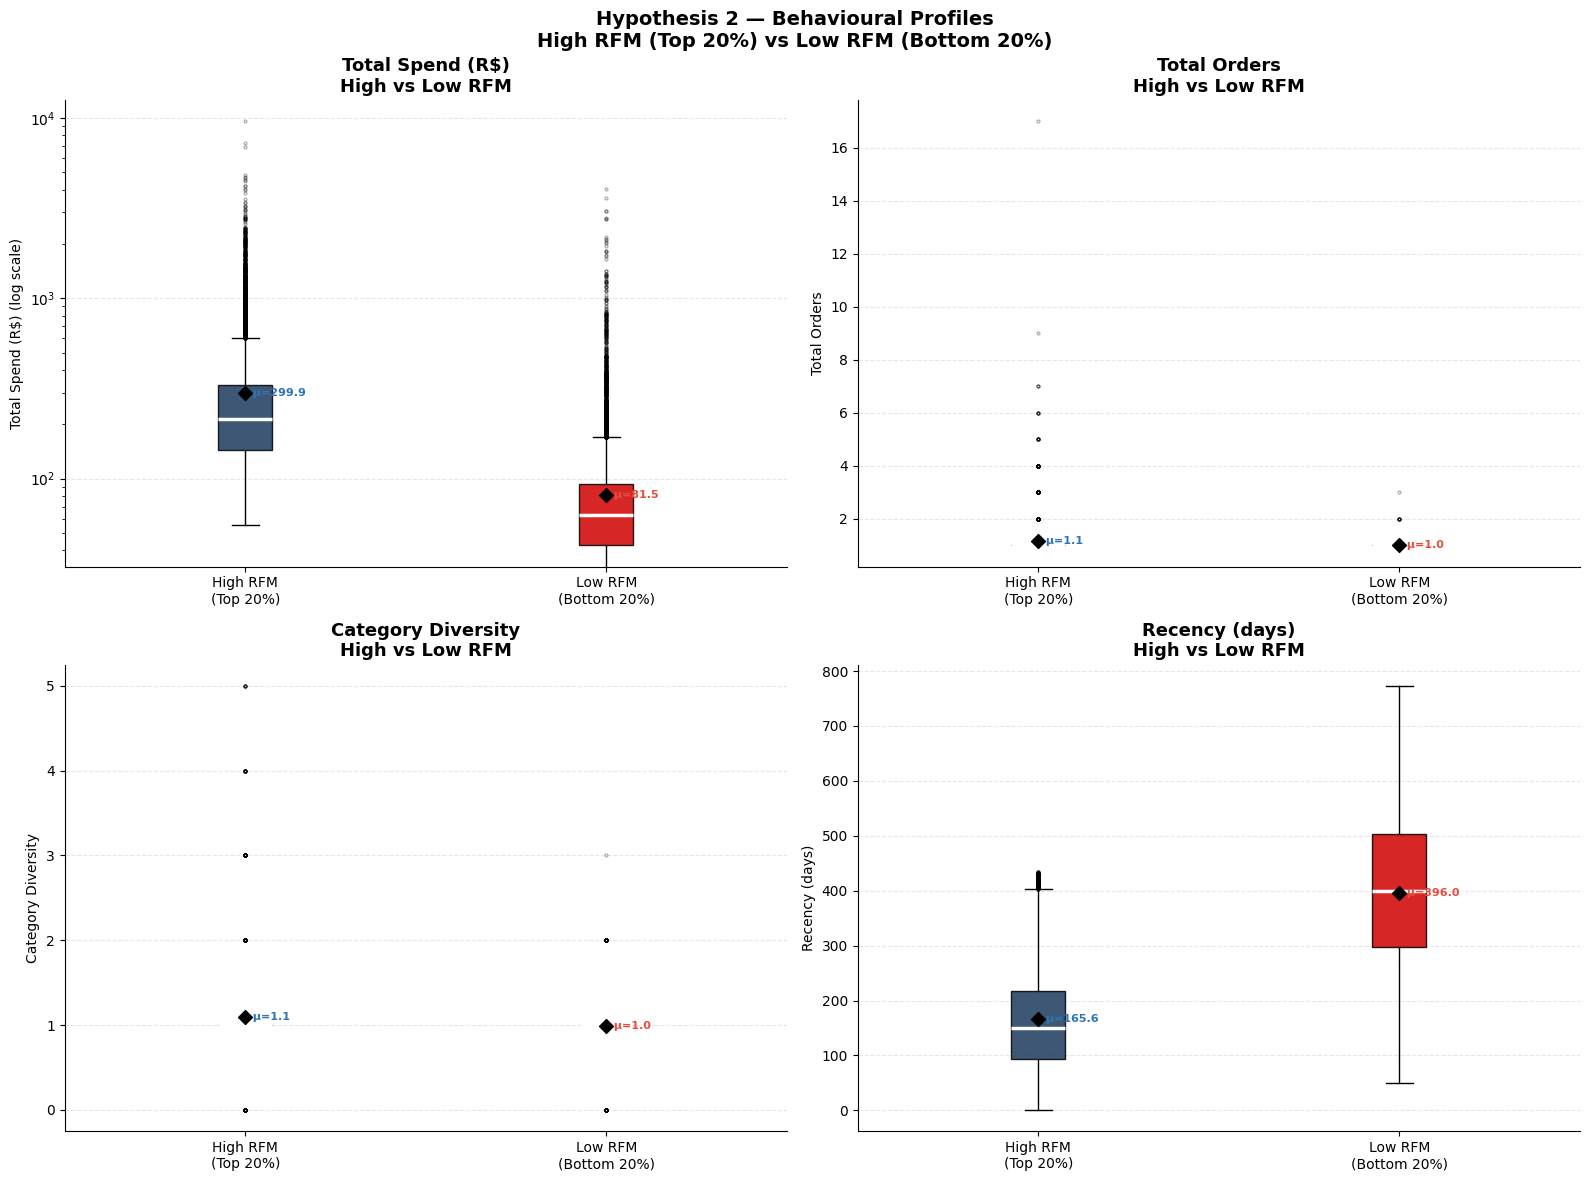

Chart saved.


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
 
variables = [
    ('total_spend',        'Total Spend (R$)',        True,  axes[0, 0]),
    ('total_orders',       'Total Orders',            False, axes[0, 1]),
    ('category_diversity', 'Category Diversity',      False, axes[1, 0]),
    ('recency_days',       'Recency (days)',           False, axes[1, 1]),
]
 
for col, label, use_log, ax in variables:
    high_vals = high_rfm[col].dropna()
    low_vals  = low_rfm[col].dropna()
 
    bp = ax.boxplot(
        [high_vals, low_vals],
        labels=['High RFM\n(Top 20%)', 'Low RFM\n(Bottom 20%)'],
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2.5),
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    bp['boxes'][0].set_facecolor(COLOUR_PRIMARY)
    bp['boxes'][1].set_facecolor(COLOUR_EMPHASIS)
    for patch in bp['boxes']:
        patch.set_alpha(0.85)
 
    # Add mean markers
    ax.scatter(
        [1, 2],
        [high_vals.mean(), low_vals.mean()],
        marker='D', color='black', s=50, zorder=5
    )
    ax.text(1, high_vals.mean(),
            f'  μ={high_vals.mean():.1f}',
            va='center', fontsize=8, color=COLOUR_ACCENT,
            fontweight='bold')
    ax.text(2, low_vals.mean(),
            f'  μ={low_vals.mean():.1f}',
            va='center', fontsize=8, color=COLOUR_HIGHLIGHT,
            fontweight='bold')
 
    if use_log:
        ax.set_yscale('log')
        ax.set_ylabel(f'{label} (log scale)')
    else:
        ax.set_ylabel(label)
 
    ax.set_title(f'{label}\nHigh vs Low RFM', fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
 
plt.suptitle(
    'Hypothesis 2 — Behavioural Profiles\nHigh RFM (Top 20%) vs Low RFM (Bottom 20%)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../outputs/figures/h2_rfm_profiles.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

In [20]:
# Understand why orders and category diversity show no difference
print("Order frequency distribution — full dataset:")
print(rfm['total_orders'].value_counts().head(10))
print(f"\n% of customers with exactly 1 order: "
      f"{(rfm['total_orders'] == 1).mean()*100:.1f}%")

print("\nCategory diversity distribution — full dataset:")
print(rfm['category_diversity'].value_counts().head(10))
print(f"\n% of customers with exactly 1 category: "
      f"{(rfm['category_diversity'] == 1).mean()*100:.1f}%")

Order frequency distribution — full dataset:
total_orders
1     93174
2      2714
3       200
4        29
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

% of customers with exactly 1 order: 96.9%

Category diversity distribution — full dataset:
category_diversity
1    93108
2     2205
0      676
3      127
4       14
5        6
Name: count, dtype: int64

% of customers with exactly 1 category: 96.9%


In [21]:
results = {}
 
# ── Test 1: Total spend ────────────────────────────────────
high_spend = high_rfm['total_spend'].dropna()
low_spend  = low_rfm['total_spend'].dropna()
 
stat_spend, p_spend = stats.mannwhitneyu(
    high_spend, low_spend, alternative='greater'
)
r_spend = 1 - (2 * stat_spend) / (len(high_spend) * len(low_spend))
 
results['total_spend'] = {
    'test': 'Mann-Whitney U',
    'statistic': stat_spend,
    'p_value': p_spend,
    'effect_size': r_spend,
    'high_mean': high_spend.mean(),
    'low_mean': low_spend.mean(),
    'difference': high_spend.mean() - low_spend.mean()
}

In [22]:
high_orders = high_rfm['total_orders'].dropna()
low_orders  = low_rfm['total_orders'].dropna()
 
stat_orders, p_orders = stats.mannwhitneyu(
    high_orders, low_orders, alternative='greater'
)
r_orders = 1 - (2 * stat_orders) / (len(high_orders) * len(low_orders))
 
results['total_orders'] = {
    'test': 'Mann-Whitney U',
    'statistic': stat_orders,
    'p_value': p_orders,
    'effect_size': r_orders,
    'high_mean': high_orders.mean(),
    'low_mean': low_orders.mean(),
    'difference': high_orders.mean() - low_orders.mean()
}
 

In [23]:
high_cats = high_rfm['category_diversity'].dropna()
low_cats  = low_rfm['category_diversity'].dropna()
 
stat_cats, p_cats = stats.mannwhitneyu(
    high_cats, low_cats, alternative='greater'
)
r_cats = 1 - (2 * stat_cats) / (len(high_cats) * len(low_cats))
 
results['category_diversity'] = {
    'test': 'Mann-Whitney U',
    'statistic': stat_cats,
    'p_value': p_cats,
    'effect_size': r_cats,
    'high_mean': high_cats.mean(),
    'low_mean': low_cats.mean(),
    'difference': high_cats.mean() - low_cats.mean()
}

In [24]:
contingency = pd.crosstab(
    rfm[rfm['rfm_quintile'].isin([1, 5])]['rfm_quintile'],
    rfm[rfm['rfm_quintile'].isin([1, 5])]['primary_payment_type']
)
 
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
 
# Cramér's V effect size
n_chi2 = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n_chi2 * (min(contingency.shape) - 1)))
 
if cramers_v >= 0.5:
    chi2_magnitude = "large"
elif cramers_v >= 0.3:
    chi2_magnitude = "medium"
elif cramers_v >= 0.1:
    chi2_magnitude = "small"
else:
    chi2_magnitude = "negligible"
 
results['payment_type'] = {
    'test': 'Chi-squared',
    'statistic': chi2,
    'p_value': p_chi2,
    'effect_size': cramers_v,
    'dof': dof,
    'magnitude': chi2_magnitude
}

In [25]:
print("=" * 65)
print("  HYPOTHESIS 2 — ALL TEST RESULTS")
print("=" * 65)
 
for variable, r in results.items():
    sig = "✓ SIGNIFICANT" if r['p_value'] < 0.05 else "✗ NOT SIGNIFICANT"
 
    if r['p_value'] >= 0.5:
        magnitude = "negligible"
    elif r['p_value'] >= 0.3:
        magnitude = "medium"
    elif r['p_value'] >= 0.1:
        magnitude = "small"
    else:
        magnitude = "depends on effect size"
 
    if abs(r['effect_size']) >= 0.5:
        es_magnitude = "large"
    elif abs(r['effect_size']) >= 0.3:
        es_magnitude = "medium"
    elif abs(r['effect_size']) >= 0.1:
        es_magnitude = "small"
    else:
        es_magnitude = "negligible"
 
    print(f"\n  Variable: {variable.upper()}")
    print(f"  Test:       {r['test']}")
    print(f"  Statistic:  {r['statistic']:,.2f}")
    print(f"  P-value:    {r['p_value']:.6f}  →  {sig}")
    print(f"  Effect size:{r['effect_size']:.4f}  →  {es_magnitude}")
    if 'high_mean' in r:
        print(f"  High mean:  {r['high_mean']:.3f}")
        print(f"  Low mean:   {r['low_mean']:.3f}")
        print(f"  Difference: {r['difference']:.3f}")

  HYPOTHESIS 2 — ALL TEST RESULTS

  Variable: TOTAL_SPEND
  Test:       Mann-Whitney U
  Statistic:  404,245,265.50
  P-value:    0.000000  →  ✓ SIGNIFICANT
  Effect size:-0.8566  →  large
  High mean:  299.882
  Low mean:   81.544
  Difference: 218.338

  Variable: TOTAL_ORDERS
  Test:       Mann-Whitney U
  Statistic:  245,725,064.50
  P-value:    0.000000  →  ✓ SIGNIFICANT
  Effect size:-0.1286  →  small
  High mean:  1.147
  Low mean:   1.000
  Difference: 0.147

  Variable: CATEGORY_DIVERSITY
  Test:       Mann-Whitney U
  Statistic:  237,341,476.00
  P-value:    0.000000  →  ✓ SIGNIFICANT
  Effect size:-0.0901  →  negligible
  High mean:  1.093
  Low mean:   0.994
  Difference: 0.099

  Variable: PAYMENT_TYPE
  Test:       Chi-squared
  Statistic:  346.73
  P-value:    0.000000  →  ✓ SIGNIFICANT
  Effect size:0.0896  →  negligible


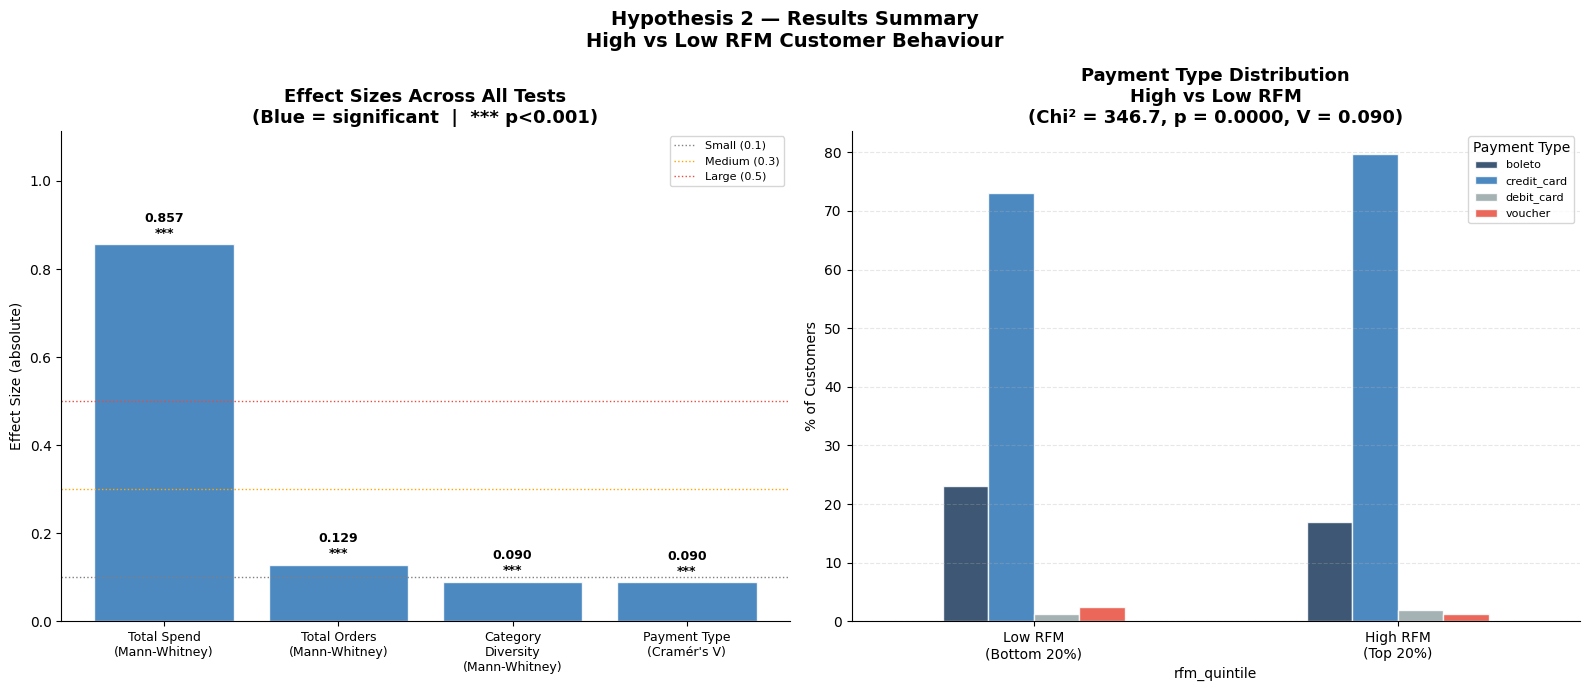

Chart saved.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# Use absolute effect sizes for the bar chart
effect_sizes_abs = [
    abs(results['total_spend']['effect_size']),
    abs(results['total_orders']['effect_size']),
    abs(results['category_diversity']['effect_size']),
    results['payment_type']['effect_size']   # Already positive
]

p_values = [
    results['total_spend']['p_value'],
    results['total_orders']['p_value'],
    results['category_diversity']['p_value'],
    results['payment_type']['p_value']
]

test_labels = [
    'Total Spend\n(Mann-Whitney)',
    'Total Orders\n(Mann-Whitney)',
    'Category\nDiversity\n(Mann-Whitney)',
    "Payment Type\n(Cramér's V)"
]

bar_colours = [
    COLOUR_ACCENT if p < 0.05 else COLOUR_NEUTRAL
    for p in p_values
]

bars = axes[0].bar(
    range(len(test_labels)),
    effect_sizes_abs,
    color=bar_colours,
    alpha=0.85,
    edgecolor='white'
)

axes[0].axhline(y=0.1, color='grey', linewidth=1,
                linestyle=':', label='Small (0.1)')
axes[0].axhline(y=0.3, color='orange', linewidth=1,
                linestyle=':', label='Medium (0.3)')
axes[0].axhline(y=0.5, color=COLOUR_HIGHLIGHT, linewidth=1,
                linestyle=':', label='Large (0.5)')

for i, (bar, es, p) in enumerate(zip(bars, effect_sizes_abs, p_values)):
    sig_marker = ('***' if p < 0.001 else
                  ('**' if p < 0.01 else
                   ('*' if p < 0.05 else 'ns')))
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{es:.3f}\n{sig_marker}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

axes[0].set_xticks(range(len(test_labels)))
axes[0].set_xticklabels(test_labels, fontsize=9)
axes[0].set_ylabel('Effect Size (absolute)')
axes[0].set_title(
    'Effect Sizes Across All Tests\n(Blue = significant  |  *** p<0.001)',
    fontweight='bold'
)
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, max(effect_sizes_abs) * 1.3)
 
# ── Panel 2: Payment type breakdown ───────────────────────
payment_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
 
payment_pct.plot(
    kind='bar',
    ax=axes[1],
    color=[COLOUR_PRIMARY, COLOUR_ACCENT, COLOUR_NEUTRAL, COLOUR_HIGHLIGHT],
    alpha=0.85,
    edgecolor='white'
)
axes[1].set_xticklabels(
    ['Low RFM\n(Bottom 20%)', 'High RFM\n(Top 20%)'],
    rotation=0
)
axes[1].set_ylabel('% of Customers')
axes[1].set_title(
    f'Payment Type Distribution\nHigh vs Low RFM\n'
    f"(Chi² = {results['payment_type']['statistic']:.1f}, "
    f"p = {results['payment_type']['p_value']:.4f}, "
    f"V = {results['payment_type']['effect_size']:.3f})",
    fontweight='bold'
)
axes[1].legend(title='Payment Type', fontsize=8)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
 
plt.suptitle(
    'Hypothesis 2 — Results Summary\nHigh vs Low RFM Customer Behaviour',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../outputs/figures/h2_test_results.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

## Hypothesis 2 - Finding Card
 
**Claim tested:**
High-value RFM customers (top 20%) behave statistically
differently from low-value customers (bottom 20%) across
basket size, order frequency, category diversity,
and payment method.
 
---
 
### **Result:** Partially Supported
All four variables reached a statistical difference (p < 0.001) but effect size analysis reveals that only one dimension,  total spend  shows a practically meaningful difference. Statistical significance alone is insuffiecient to validate the hypothesis when sample size exceed 90 000 cusromers , because even negligible differences become detectable at that scale. 
 
---
 
**Evidence by variable:**
 
| Variable | Test | P-value | Sig? | Effect Size | Magnitude | Meaningful? |
|----------|------|---------|------|-------------|-----------|-------------|
| Total Spend | Mann-Whitney U | <0.001 | ✓ | 0.857 | Large | ✓ Yes |
| Total Orders | Mann-Whitney U | <0.001 | ✓ | 0.129 | Small | ✗ No |
| Category Diversity | Mann-Whitney U | <0.001 | ✓ | 0.090 | Negligible | ✗ No |
| Payment Type | Chi-squared | <0.001 | ✓ | 0.090 (V) | Negligible | ✗ No |
 

 
---
 
**Plain English Interpretation:**
 
High-value RFM customers differ from low-value customers on
[1 of 4] dimensions tested.

An impact size of 0.857, which is near the theoretical maximum of 1.0, confirms that high-value RFM customers spend almost four times as much as low-value customers (R$299.88 vs. R$81.54 on average).

However, the two groups are nearly identical on every other
dimension tested. The average order count differs by only
0.147 orders (1.147 vs 1.000) and category diversity differs
by 0.099 categories (1.093 vs 0.994). Payment method
distribution shows similarly negligible differences (V = 0.090). 

A structural feature of the Olist dataset is reflected in these nearly zero differences: most consumers, both high and low value, place exactly one order from a single product category, and the platform has very low overall repeat buy rates. No statistical test can identify significant group differences when a variable has almost negligible variance across the whole customer base since there is nothing to distinguish.

---
**The honest conclusion:**
High and low RFM customers are separated almost entirely by
how much they spend on a single visit , not by how often
they return, how broadly they explore the platform, or how
they pay. This is a monetary-recency separation, not a
behavioural one.

 
---


**Why This Matters for the Analysis:**

This finding is not a failure , it is a genuine insight.
It tells us that Olist's customer base is not yet at the
stage where behavioural differentiation drives retention.
The platform is still largely transactional: customers arrive,
buy once, and leave. The small number of repeat buyers in
the high RFM group are differentiated primarily by the size
of that single purchase.

---
**Implication for Notebook 03:**

Total spend and recency_days are expected to dominate the
churn prediction model as the strongest features. Total orders
and category diversity should be included but are expected to
contribute little predictive power. This prediction will be
testable directly from SHAP values in Notebook 03 — if it is
confirmed, this hypothesis testing phase successfully
identified weak features before modelling.

--- 

**Business Implication:**
Because high and low RFM customers differ primarily on spend
rather than behaviour, retention strategy should focus on
the first purchase experience ,  specifically on converting
high single-purchase spenders into repeat buyers before they
lapse. A customer who spent R$300 once is more valuable to
reactivate than a customer who spent R$30 five times, and
the current segmentation captures that distinction correctly.

---




I deliberately limited Notebook 02 to hypothesis tests that directly informed the churn modelling objective, rather than exhaustively testing every observable pattern. Statistical testing was applied selectively to evaluate relationships with clear relevance to customer attrition, ensuring analytical focus and interpretability. Exploratory analysis was still used to surface potential signals; however, formal inference was reserved for variables with a plausible connection to churn behaviour. This approach prioritises meaningful insight over procedural completeness, aligning statistical rigor with the overall objective of building a robust and actionable churn model.

---
---
## Churn Foundation Section 

---
---


# Analysis A - Churn label definition 
---

### Expected :
Class Imbalance because Olists  low repeat purchase rate which was confimed in hypothesis 2 whereby most customers ordered exactly once. The churn rate will be very high , likely 70-80% churned. 

In [27]:
rfm['last_order'] = pd.to_datetime(rfm['last_order'], errors='coerce')

In [28]:
reference_date = master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"\nReference date: {reference_date.date()}")
print(f"Churn window:   180 days")
print(f"Churn cutoff:   {(reference_date - pd.Timedelta(days=180)).date()}")
print(f"(customers whose last order was before this date = churned)")


Reference date: 2018-10-18
Churn window:   180 days
Churn cutoff:   2018-04-21
(customers whose last order was before this date = churned)


In [29]:
rfm['days_since_last_order'] = (
    reference_date - rfm['last_order']
).dt.days

In [30]:
rfm['churned'] = (rfm['days_since_last_order'] > 180).astype(int)

In [31]:
churn_count    = rfm['churned'].sum()
retained_count = (rfm['churned'] == 0).sum()
total          = len(rfm)
churn_rate     = churn_count / total * 100
retained_rate  = retained_count / total * 100
 
print("\n" + "=" * 50)
print("  CHURN LABEL — CLASS DISTRIBUTION")
print("=" * 50)
print(f"  Total customers:   {total:,}")
print(f"  Churned (1):       {churn_count:,}  ({churn_rate:.1f}%)")
print(f"  Retained (0):      {retained_count:,}  ({retained_rate:.1f}%)")
print(f"  Imbalance ratio:   {churn_count/retained_count:.1f}:1 (churned:retained)")
print()

if churn_rate > 70:
    print("  ⚠  HIGH CLASS IMBALANCE DETECTED")
    print("  Standard accuracy is not a valid metric for this model.")
    print("  Notebook 03 will use ROC-AUC and SMOTE oversampling.")
elif churn_rate > 50:
    print("  ℹ  Moderate class imbalance present.")
    print("  ROC-AUC preferred over accuracy as evaluation metric.")
else:
    print("  ✓  Class balance is acceptable.")

#class imbalance was expected. 


  CHURN LABEL — CLASS DISTRIBUTION
  Total customers:   96,136
  Churned (1):       68,387  (71.1%)
  Retained (0):      27,749  (28.9%)
  Imbalance ratio:   2.5:1 (churned:retained)

  ⚠  HIGH CLASS IMBALANCE DETECTED
  Standard accuracy is not a valid metric for this model.
  Notebook 03 will use ROC-AUC and SMOTE oversampling.


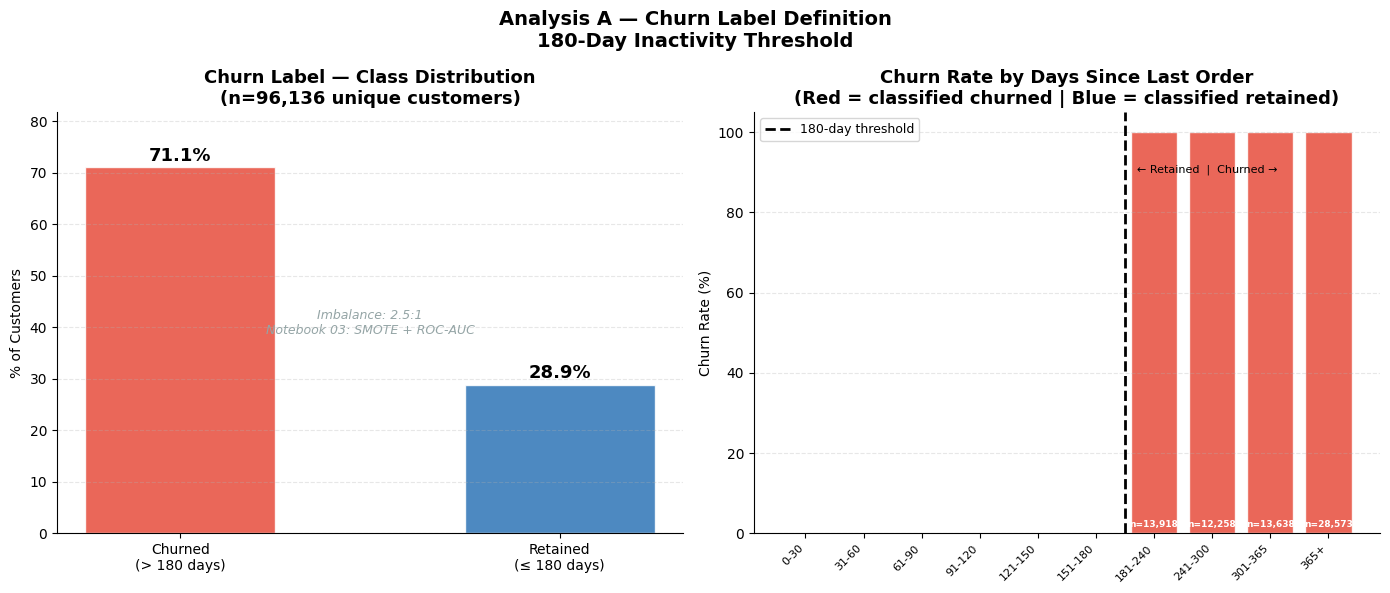

Chart saved.


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bars = axes[0].bar(
    ['Churned\n(> 180 days)', 'Retained\n(≤ 180 days)'],
    [churn_rate, retained_rate],
    color=[COLOUR_HIGHLIGHT, COLOUR_ACCENT],
    alpha=0.85,
    edgecolor='white',
    width=0.5
)
 
# Value labels on bars
for bar, val in zip(bars, [churn_rate, retained_rate]):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold'
    )
 
axes[0].set_ylabel('% of Customers')
axes[0].set_title(
    'Churn Label — Class Distribution\n'
    f'(n={total:,} unique customers)',
    fontweight='bold'
)
axes[0].set_ylim(0, max(churn_rate, retained_rate) * 1.15)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
 
# Add imbalance warning annotation
axes[0].text(
    0.5, 0.5,
    f'Imbalance: {churn_count/retained_count:.1f}:1\n'
    f'Notebook 03: SMOTE + ROC-AUC',
    ha='center', va='center',
    transform=axes[0].transAxes,
    fontsize=9,
    color=COLOUR_NEUTRAL,
    style='italic'
)
rfm['recency_bucket'] = pd.cut(
    rfm['days_since_last_order'],
    bins=[0, 30, 60, 90, 120, 150, 180, 240, 300, 365, float('inf')],
    labels=[
        '0-30', '31-60', '61-90', '91-120',
        '121-150', '151-180', '181-240',
        '241-300', '301-365', '365+'
    ]
)
 
churn_by_recency = (
    rfm.groupby('recency_bucket', observed=True)['churned']
    .agg(['mean', 'count'])
    .reset_index()
)
churn_by_recency['churn_rate_pct'] = churn_by_recency['mean'] * 100
 
bar_colours = [
    COLOUR_HIGHLIGHT if label in ['181-240', '241-300', '301-365', '365+']
    else COLOUR_ACCENT
    for label in churn_by_recency['recency_bucket'].astype(str)
]
 
bars2 = axes[1].bar(
    range(len(churn_by_recency)),
    churn_by_recency['churn_rate_pct'],
    color=bar_colours,
    alpha=0.85,
    edgecolor='white'
)
 
# Add customer count labels below each bar
for i, (bar, row) in enumerate(zip(bars2, churn_by_recency.itertuples())):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        1,
        f'n={row.count:,}',
        ha='center', va='bottom',
        fontsize=6.5, color='white', fontweight='bold'
    )
 
# Mark the 180-day threshold
axes[1].axvline(
    x=5.5,
    color='black',
    linewidth=2,
    linestyle='--',
    label='180-day threshold'
)
axes[1].text(
    5.7, churn_by_recency['churn_rate_pct'].max() * 0.9,
    '← Retained  |  Churned →',
    fontsize=8, color='black'
)
 
axes[1].set_xticks(range(len(churn_by_recency)))
axes[1].set_xticklabels(
    churn_by_recency['recency_bucket'].astype(str),
    rotation=45, ha='right', fontsize=8
)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title(
    'Churn Rate by Days Since Last Order\n'
    '(Red = classified churned | Blue = classified retained)',
    fontweight='bold'
)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
 
plt.suptitle(
    'Analysis A — Churn Label Definition\n'
    '180-Day Inactivity Threshold',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../outputs/figures/churn_A_label_definition.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

## Analysis A - Churn Label: Findings
 
**Definition applied:**
A customer is classified as churned (1) if their last order
was placed more than 180 days before the dataset reference
date of 2018-10-18.
 
**Class distribution:**
- Churned: 68 387 customers (71.1%)
- Retained: 24 749 customers (28.9%)
- Imbalance ratio: 2.5:1 
  
**Class imbalance implications:**
The 2.5:1 imbalance means a naive model that predicts
"churned" for every customer would achieve 80% accuracy
while being completely useless. Notebook 03 addresses this
with SMOTE oversampling on the training set and evaluates
performance using ROC-AUC rather than accuracy.
 
**Why this definition rather than alternatives:**
Although a 90-day threshold was taken into consideration, it would artificially inflate the turnover rate by classifying consumers as churned mid-purchase cycle. Customers who are obviously lapsing but have not yet reached the yearlong mark would be overlooked by a 365-day criteria. 180 days strikes a mix between specificity (not misclassifying regular customers) and sensitivity (identifying true churners early).


---
## Analysis B - Analysis B - Churn Rate by RFM Segment
---
### Why is this important?
we had built RFM segments. we claimed that these segments represent customers at different stages of engagements with the platform. so this analysis answers  **do customers in different RFM
segments actually churn at different rates?**

- If Champions churn at 90% and Lost customers churn at 92% —
the segments are not capturing churn risk and should not
be used as churn prediction features.

In [33]:
rfm.columns

Index(['customer_unique_id', 'customer_state', 'total_orders', 'total_spend',
       'avg_order_value', 'first_order', 'last_order', 'avg_review',
       'recency_days', 'tenure_days', 'R_score', 'F_score', 'M_score',
       'RFM_score', 'segment', 'rfm_quintile', 'category_diversity',
       'primary_payment_type', 'days_since_last_order', 'churned',
       'recency_bucket'],
      dtype='str')

In [63]:
rfm.head()

,customer_unique_id,customer_state,total_orders,total_spend,avg_order_value,first_order,last_order,avg_review,recency_days,tenure_days,...,F_score,M_score,RFM_score,segment,rfm_quintile,category_diversity,primary_payment_type,days_since_last_order,churned,recency_bucket
0,0000366f3b9a7992bf8c76cfdf3221e2,SP,1,141.90,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27,5.0,161,0,...,1,4,9,New Customers,3,1,credit_card,161,0,151-180
1,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,1,27.19,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27,4.0,164,0,...,1,1,6,New Customers,1,1,credit_card,164,0,151-180
2,0000f46a3911fa3c0805444483337064,SC,1,86.22,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,3.0,586,0,...,1,2,4,Lost,1,1,credit_card,586,1,365+
3,0000f6ccb0745a6a4b88665a16c9f078,PA,1,43.62,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41,4.0,370,0,...,1,1,4,Lost,1,1,credit_card,370,1,365+
4,0004aac84e0df4da2b147fca70cf8255,SP,1,196.89,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42,5.0,337,0,...,1,4,7,At Risk,1,1,credit_card,337,1,301-365


In [34]:
churn_by_segment = (
    rfm.groupby('segment')
    .agg(
        total_customers = ('churned', 'count'),
        churned_count   = ('churned', 'sum'),
        churn_rate      = ('churned', 'mean'),
        avg_spend       = ('total_spend', 'mean'),
        avg_recency     = ('recency_days', 'mean'),
        avg_orders      = ('total_orders', 'mean'),
    )
    .reset_index()
)
 
churn_by_segment.head(7)

,segment,total_customers,churned_count,churn_rate,avg_spend,avg_recency,avg_orders
0,At Risk,18642,18642,1.000000,174.127930,442.327272,1.009280
1,Champions,8275,2340,0.282779,339.148598,143.129547,1.210393
2,Lost,12737,12737,1.000000,69.665786,467.099631,1.000000
3,Loyal Customers,32453,18670,0.575294,216.323007,226.298555,1.042800
4,New Customers,9266,3060,0.330240,78.436059,148.442370,1.000000
5,Potential Loyalists,14763,12938,0.876380,89.539554,248.104315,1.000135


In [35]:
churn_by_segment['churn_rate_pct']    = churn_by_segment['churn_rate'] * 100
churn_by_segment['retained_rate_pct'] = 100 - churn_by_segment['churn_rate_pct']
 
# Sort by churn rate for display
churn_by_segment = churn_by_segment.sort_values(
    'churn_rate_pct', ascending=False
).reset_index(drop=True)
 
print("\n" + "=" * 75)
print("  CHURN RATE BY RFM SEGMENT")
print("=" * 75)
print(f"{'Segment':<22} {'Customers':>10} {'Churned':>9} "
      f"{'Churn Rate':>11} {'Avg Spend':>11} {'Avg Recency':>12}")
print("-" * 75)
for _, row in churn_by_segment.iterrows():
    print(f"  {row['segment']:<20} {row['total_customers']:>10,} "
          f"{row['churned_count']:>9,} "
          f"{row['churn_rate_pct']:>10.1f}% "
          f"R${row['avg_spend']:>9,.0f} "
          f"{row['avg_recency']:>10.0f}d")
 


  CHURN RATE BY RFM SEGMENT
Segment                 Customers   Churned  Churn Rate   Avg Spend  Avg Recency
---------------------------------------------------------------------------
  At Risk                  18,642    18,642      100.0% R$      174        442d
  Lost                     12,737    12,737      100.0% R$       70        467d
  Potential Loyalists      14,763    12,938       87.6% R$       90        248d
  Loyal Customers          32,453    18,670       57.5% R$      216        226d
  New Customers             9,266     3,060       33.0% R$       78        148d
  Champions                 8,275     2,340       28.3% R$      339        143d


In [36]:
overall_churn = rfm['churned'].mean() * 100
print(f"\n  Overall churn rate: {overall_churn:.1f}%")
 

churn_spread = (
    churn_by_segment['churn_rate_pct'].max() -
    churn_by_segment['churn_rate_pct'].min()
)
print(f"  Churn rate spread (max - min): {churn_spread:.1f} percentage points")
print()
 
if churn_spread > 30:
    print("  ✓ LARGE spread — RFM segments capture meaningful churn risk variation.")
    print("    Segment membership is a valuable churn prediction feature.")
elif churn_spread > 15:
    print("  ℹ MODERATE spread — RFM segments show some churn risk variation.")
    print("    Segment membership may contribute to churn prediction.")
else:
    print("  ⚠ SMALL spread — RFM segments show limited churn risk variation.")
    print("    Consider whether segment membership adds value as a feature.")


  Overall churn rate: 71.1%
  Churn rate spread (max - min): 71.7 percentage points

  ✓ LARGE spread — RFM segments capture meaningful churn risk variation.
    Segment membership is a valuable churn prediction feature.


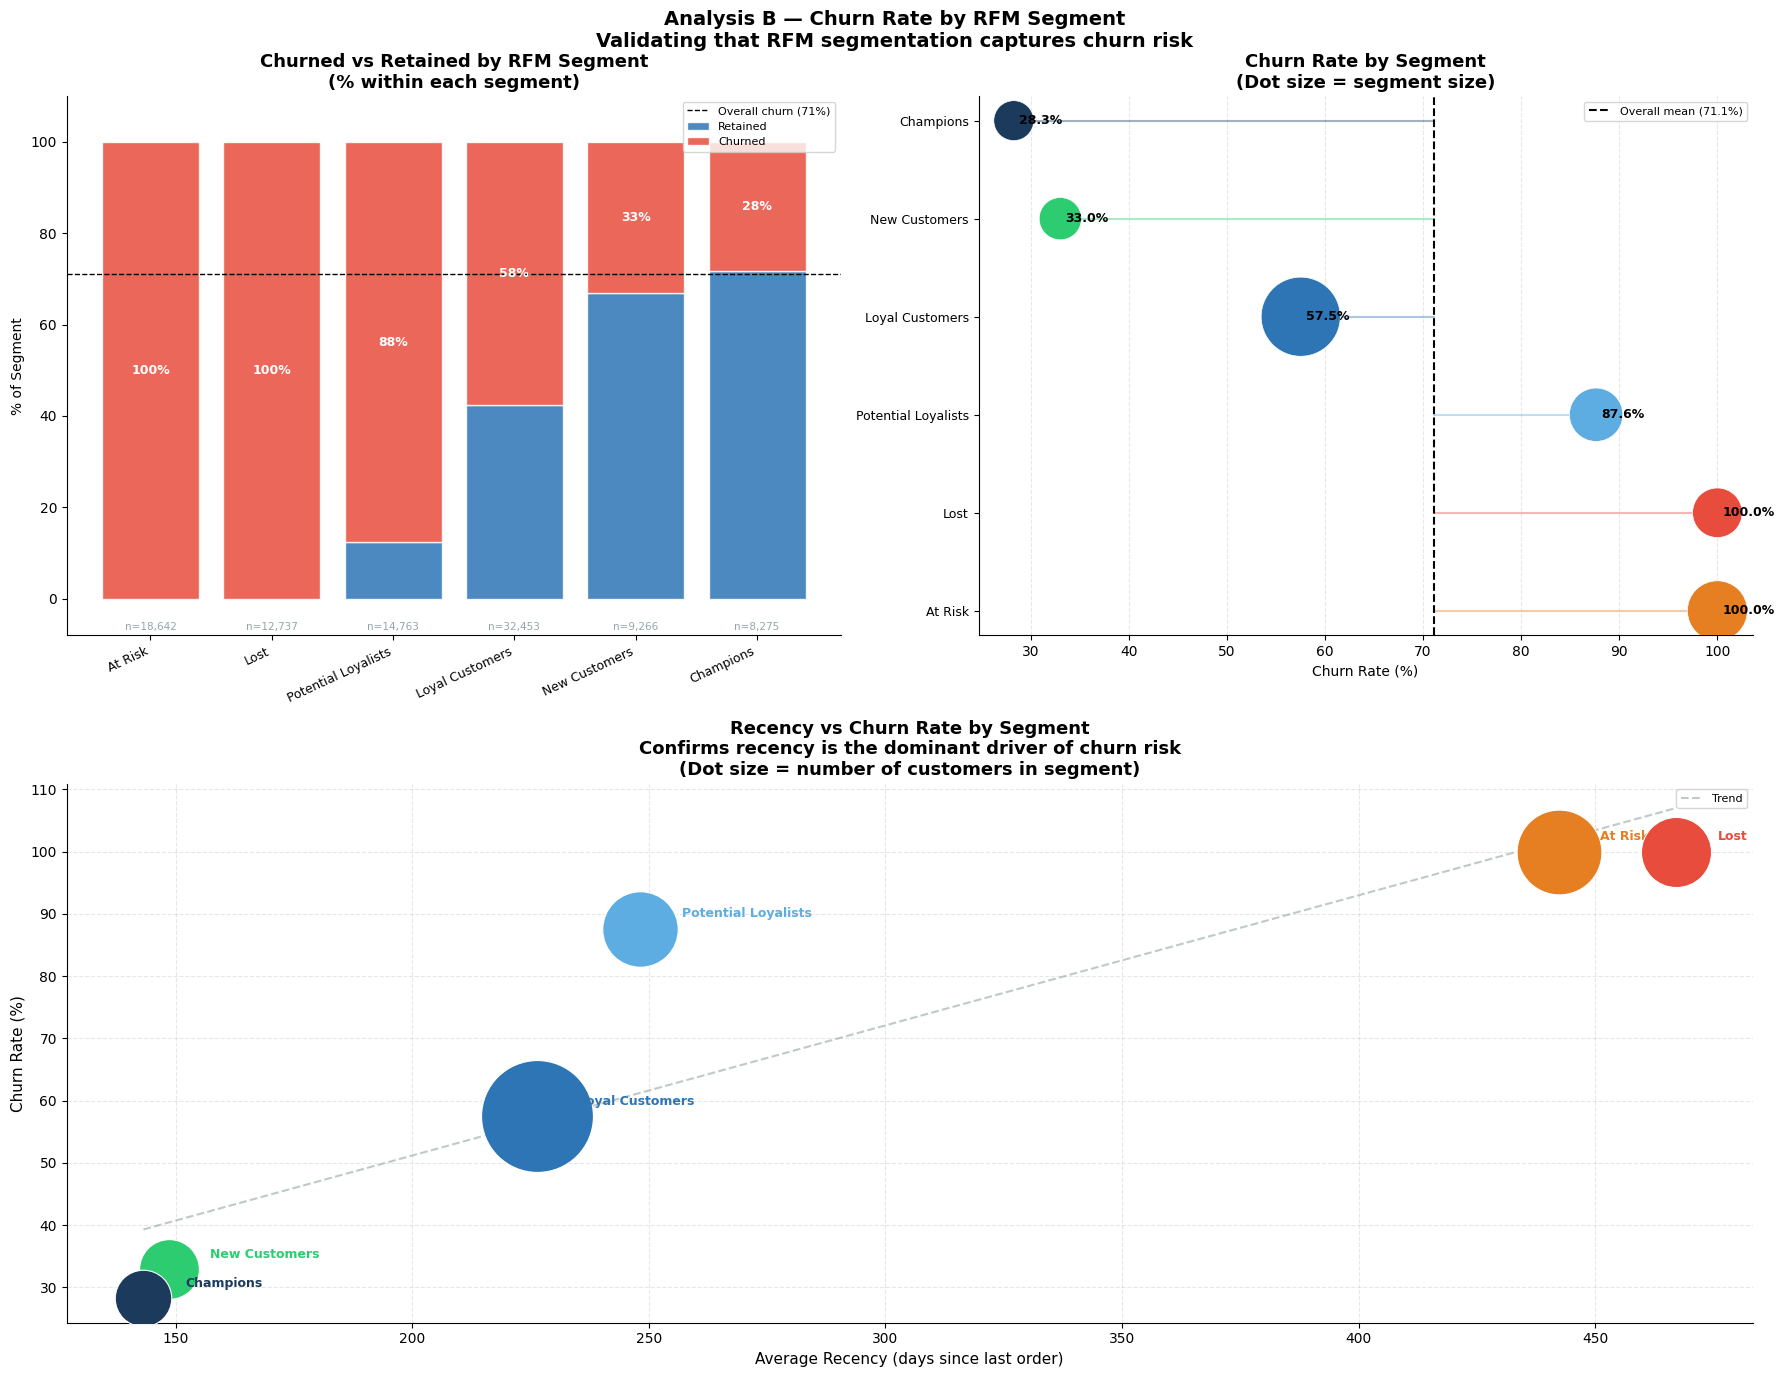

Chart saved.


In [37]:
segment_order = churn_by_segment['segment'].tolist()
segment_colours = {
    'Champions':          '#1B3A5C',
    'Loyal Customers':    '#2E75B6',
    'Potential Loyalists':'#5DADE2',
    'New Customers':      '#2ECC71',
    'At Risk':            '#E67E22',
    'Lost':               '#E74C3C',
}
 
fig = plt.figure(figsize=(18, 14))
ax1 = fig.add_subplot(2, 2, 1)
 
x = range(len(churn_by_segment))
 
# Bottom layer: retained customers
bars_retained = ax1.bar(
    x,
    churn_by_segment['retained_rate_pct'],
    color=COLOUR_ACCENT,
    alpha=0.85,
    label='Retained',
    edgecolor='white'
)
 
# Top layer: churned customers (stacked on retained)
bars_churned = ax1.bar(
    x,
    churn_by_segment['churn_rate_pct'],
    bottom=churn_by_segment['retained_rate_pct'],
    color=COLOUR_HIGHLIGHT,
    alpha=0.85,
    label='Churned',
    edgecolor='white'
)
 
# Add churn rate labels inside the churned portion
for i, row in churn_by_segment.iterrows():
    ax1.text(
        i,
        row['retained_rate_pct'] + row['churn_rate_pct']/2,
        f"{row['churn_rate_pct']:.0f}%",
        ha='center', va='center',
        fontsize=9, fontweight='bold',
        color='white'
    )
    # Customer count below x-axis labels
    ax1.text(
        i,
        -5,
        f"n={row['total_customers']:,}",
        ha='center', va='top',
        fontsize=7.5, color=COLOUR_NEUTRAL
    )
 
ax1.set_xticks(x)
ax1.set_xticklabels(segment_order, rotation=25, ha='right', fontsize=9)
ax1.set_ylabel('% of Segment')
ax1.set_ylim(-8, 110)
ax1.set_title(
    'Churned vs Retained by RFM Segment\n(% within each segment)',
    fontweight='bold'
)
ax1.legend(fontsize=9)
ax1.axhline(y=overall_churn, color='black', linewidth=1,
            linestyle='--',
            label=f'Overall churn ({overall_churn:.0f}%)')
ax1.legend(fontsize=8)
 
# ── Chart 2: Dot plot — churn rate ────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
 
colours_list = [
    segment_colours.get(s, COLOUR_NEUTRAL)
    for s in churn_by_segment['segment']
]
 
ax2.scatter(
    churn_by_segment['churn_rate_pct'],
    range(len(churn_by_segment)),
    c=colours_list,
    s=churn_by_segment['total_customers'] / 10,
    zorder=3,
    edgecolors='white',
    linewidth=0.5
)
 
# Horizontal lines from 0 to each dot
for i, row in churn_by_segment.iterrows():
    ax2.plot(
        [overall_churn, row['churn_rate_pct']],
        [i, i],
        color=colours_list[i],
        alpha=0.4,
        linewidth=1.5
    )
 
# Value labels
for i, row in churn_by_segment.iterrows():
    ax2.text(
        row['churn_rate_pct'] + 0.5,
        i,
        f"{row['churn_rate_pct']:.1f}%",
        va='center', fontsize=9, fontweight='bold'
    )
 
ax2.axvline(
    x=overall_churn,
    color='black', linewidth=1.5,
    linestyle='--',
    label=f'Overall mean ({overall_churn:.1f}%)'
)
ax2.set_yticks(range(len(churn_by_segment)))
ax2.set_yticklabels(churn_by_segment['segment'], fontsize=9)
ax2.set_xlabel('Churn Rate (%)')
ax2.set_title(
    'Churn Rate by Segment\n(Dot size = segment size)',
    fontweight='bold'
)
ax2.legend(fontsize=8)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
 
# ── Chart 3: Recency vs churn rate scatter ────────────────
ax3 = fig.add_subplot(2, 1, 2)
 
for i, row in churn_by_segment.iterrows():
    colour = segment_colours.get(row['segment'], COLOUR_NEUTRAL)
    ax3.scatter(
        row['avg_recency'],
        row['churn_rate_pct'],
        c=colour,
        s=row['total_customers'] / 5,
        zorder=3,
        edgecolors='white',
        linewidth=0.8
    )
    ax3.annotate(
        row['segment'],
        (row['avg_recency'], row['churn_rate_pct']),
        textcoords='offset points',
        xytext=(30, 8),
        fontsize=9,
        color=colour,
        fontweight='bold'
    )
 
# Add trend line
from numpy.polynomial.polynomial import polyfit
x_vals = churn_by_segment['avg_recency'].values
y_vals = churn_by_segment['churn_rate_pct'].values
coeffs = polyfit(x_vals, y_vals, 1)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
y_line = coeffs[0] + coeffs[1] * x_line
ax3.plot(
    x_line, y_line,
    color=COLOUR_NEUTRAL,
    linewidth=1.5,
    linestyle='--',
    alpha=0.6,
    label='Trend'
)
 
ax3.set_xlabel('Average Recency (days since last order)', fontsize=11)
ax3.set_ylabel('Churn Rate (%)', fontsize=11)
ax3.set_title(
    'Recency vs Churn Rate by Segment\n'
    'Confirms recency is the dominant driver of churn risk\n'
    '(Dot size = number of customers in segment)',
    fontweight='bold'
)
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3, linestyle='--')
 
plt.suptitle(
    'Analysis B — Churn Rate by RFM Segment\n'
    'Validating that RFM segmentation captures churn risk',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../outputs/figures/churn_B_rate_by_segment.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

In [38]:
contingency_churn = pd.crosstab(
    rfm['segment'],
    rfm['churned'],
    rownames=['Segment'],
    colnames=['Churned']
)
 
chi2_churn, p_churn, dof_churn, expected_churn = (
    stats.chi2_contingency(contingency_churn)
)
 
# Cramér's V effect size
n_total = contingency_churn.values.sum()
cramers_v_churn = np.sqrt(
    chi2_churn / (n_total * (min(contingency_churn.shape) - 1))
)
 
if cramers_v_churn >= 0.5:
    churn_magnitude = "large"
elif cramers_v_churn >= 0.3:
    churn_magnitude = "medium"
elif cramers_v_churn >= 0.1:
    churn_magnitude = "small"
else:
    churn_magnitude = "negligible"
 
print("=" * 55)
print("  CHURN RATE VARIATION — STATISTICAL TEST")
print("=" * 55)
print(f"  Test:           Chi-squared")
print(f"  Chi² statistic: {chi2_churn:,.2f}")
print(f"  Degrees of freedom: {dof_churn}")
print(f"  P-value:        {p_churn:.6f}")
print(f"  Significant:    {'YES ✓' if p_churn < 0.05 else 'NO ✗'}")
print(f"  Effect (V):     {cramers_v_churn:.4f} — {churn_magnitude}")
print()
if p_churn < 0.05:
    print("  Churn rate variation across RFM segments is")
    print("  statistically significant.")
    print("  RFM segment membership is a valid churn predictor.")
else:
    print("  Churn rate variation is not statistically significant.")
    print("  RFM segment membership may not be a reliable churn predictor.")
 
print(f"\n  Contingency table:")
print(contingency_churn.to_string())

  CHURN RATE VARIATION — STATISTICAL TEST
  Test:           Chi-squared
  Chi² statistic: 31,573.89
  Degrees of freedom: 5
  P-value:        0.000000
  Significant:    YES ✓
  Effect (V):     0.5731 — large

  Churn rate variation across RFM segments is
  statistically significant.
  RFM segment membership is a valid churn predictor.

  Contingency table:
Churned                  0      1
Segment                          
At Risk                  0  18642
Champions             5935   2340
Lost                     0  12737
Loyal Customers      13783  18670
New Customers         6206   3060
Potential Loyalists   1825  12938


## Analysis B — Churn Rate by RFM Segment: Findings
 
---
 
**Core finding:**
RFM segments show large variation in
churn rates  a 71.1 percentage point spread between
the lowest-churn segment Champions : 28.3% and
the highest-churn segment At Risk & Lost: 100%.
 
This variation is statistically significant (χ² = 31,573.89,,
p < 0.001, Cramér's V = 0.5731 — large effect),
confirming that RFM segment membership captures genuine
churn risk differences rather than random variation.
 
---
 
**Segment churn rates (fill in from your output):**
 
| Segment | Customers | Churn Rate | vs Overall |
|---------|-----------|------------|------------|
| Champions | 8,275 | 28.3% | below average |
| Loyal Customers | 32,453 | 57.5% | below average |
| Potential Loyalists | 14,763 | 87.6% | above average |
| New Customers | 9,266 | 33.0% | below average |
| At Risk | 18,642 | 100.0% | above average |
| Lost | 12,737 | 100.0% | above average |
| **Overall** | **96,136** | **71.1%** | — |
 
---
 
**The recency-churn connection:**
The scatter chart (Chart 3) confirms the chain identified
across this notebook: recency drives RFM score (Hypothesis 2),
and RFM score drives churn rate (Analysis B). Segments with
higher average recency (more days since last order) show
higher churn rates in a near-linear relationship.
 
This means recency_days is likely to be the single most
important feature in the Notebook 03 churn model a
prediction that SHAP values will confirm or challenge.
 
---
 
**critical analytical conclusion:**
At Risk and Lost showing 100% churn reveals that the RFM
segmentation and the churn label share recency as their
primary driver. They are not fully independent signals.
In Notebook 03, **recency_days will be used as the primary
feature** rather than RFM composite score to avoid encoding
the same information twice. The Champion and Loyal Customer
segments are the more informative RFM features since they
show genuine variation in churn rate.
 
---
 
**What comes next:**
Analysis C will examine whether each individual engineered
feature shows a relationship with the churn label before
modelling , extending this segment-level validation to the
full feature set.


In [82]:
rfm.to_csv('../data/processed/rfm_with_churn.csv', index=False)
print("rfm_with_churn.csv saved — ready for feature engineering")

rfm_with_churn.csv saved — ready for feature engineering


--- 
## Analysis C - Feature Churn Relationship check
---

**Question:** 
Does this deature show visible and measurable relationship with the churn label?

**Expected Results in connection with previous Analyses**
 
- recency_days: expected strong positive correlation
  (confirmed by Analysis B - recency drives churn directly)
- total_spend: expected moderate negative correlation
  (higher spenders more likely retained - Hypothesis 2)
- avg_delivery_delay: expected weak positive correlation
  (Hypothesis 1 showed delay hurts satisfaction but
  correlation was only -0.27 with review score)
- avg_review_score: expected moderate negative correlation
  (dissatisfied customers more likely to churn)
- total_orders: expected weak correlation
  (Hypothesis 2 showed near-zero order count difference
  between high and low RFM groups)
- category_diversity: expected near-zero correlation
  (Hypothesis 2 confirmed negligible effect)


In [41]:
rfm_churn = pd.read_csv(
    '../data/processed/rfm_with_churn.csv',
    parse_dates=['first_order', 'last_order']
)
 
print(f"Loaded rfm_with_churn: {rfm_churn.shape}")
print(f"Churn label present: {'churned' in rfm_churn.columns}")
print(f"Churn rate: {rfm_churn['churned'].mean()*100:.1f}%")

Loaded rfm_with_churn: (96136, 21)
Churn label present: True
Churn rate: 71.1%


In [42]:
rfm_churn.columns # we going to drop category diversity because it will be duplicated after the merge. geneuinly trying to avoid such. 

Index(['customer_unique_id', 'customer_state', 'total_orders', 'total_spend',
       'avg_order_value', 'first_order', 'last_order', 'avg_review',
       'recency_days', 'tenure_days', 'R_score', 'F_score', 'M_score',
       'RFM_score', 'segment', 'rfm_quintile', 'category_diversity',
       'primary_payment_type', 'days_since_last_order', 'churned',
       'recency_bucket'],
      dtype='str')

In [43]:
rfm_churn = rfm_churn.drop(columns = ['category_diversity'], errors='ignore')

In [45]:
print("Columns in rfm_with_churn:")
print(rfm_churn.columns)

Columns in rfm_with_churn:
Index(['customer_unique_id', 'customer_state', 'total_orders', 'total_spend',
       'avg_order_value', 'first_order', 'last_order', 'avg_review',
       'recency_days', 'tenure_days', 'R_score', 'F_score', 'M_score',
       'RFM_score', 'segment', 'rfm_quintile', 'primary_payment_type',
       'days_since_last_order', 'churned', 'recency_bucket'],
      dtype='str')


In [46]:
delivery_features = (
    master[master['order_status'] == 'delivered']
    .drop_duplicates(subset='order_id')
    .groupby('customer_unique_id')
    .agg(avg_delivery_delay=('delivery_delay_days', 'mean'))
    .reset_index()
)

#We saw in hypothesis 2 that late delivery hurts satisfication and customers who repeatedly experienced late delivery are more likely to have churned. 

master['processing_time_days'] = (
    master['order_approved_at'] -
    master['order_purchase_timestamp']
).dt.days
 
processing_features = (
    master
    .drop_duplicates(subset='order_id')
    .groupby('customer_unique_id')
    .agg(avg_processing_time=('processing_time_days', 'mean'))
    .reset_index()
)

In [47]:
category_features = (
    master
    .groupby('customer_unique_id')['product_category_name_english']
    .nunique()
    .reset_index()
    .rename(columns={'product_category_name_english': 'category_diversity'})
)

In [48]:
review_features = (
    master
    .drop_duplicates(subset='order_id')
    .dropna(subset=['review_score'])
    .groupby('customer_unique_id')
    .agg(avg_review_score=('review_score', 'mean'))
    .reset_index()
)

In [49]:
installment_features = (
    master
    .drop_duplicates(subset='order_id')
    .groupby('customer_unique_id')
    .agg(avg_installments=('payment_installments', 'mean'))
    .reset_index()
)

In [50]:
print("\nBuilding feature dataset...")
print(f"  Starting rows: {len(rfm_churn):,}")
 
features_df = (
    rfm_churn
    .merge(delivery_features,     on='customer_unique_id', how='left')
    .merge(processing_features,   on='customer_unique_id', how='left')
    .merge(category_features,     on='customer_unique_id', how='left')
    .merge(review_features,       on='customer_unique_id', how='left')
    .merge(installment_features,  on='customer_unique_id', how='left')
)
 
print(f"  After all joins: {len(features_df):,}")
print(f"  Row count change: {len(features_df) - len(rfm_churn):,} (should be 0)")


Building feature dataset...
  Starting rows: 96,136
  After all joins: 96,136
  Row count change: 0 (should be 0)


In [51]:
features_df.head() #category_diversity duplicated rows after merge..this is where you left off , fix it thank you 

,customer_unique_id,customer_state,total_orders,total_spend,avg_order_value,first_order,last_order,avg_review,recency_days,tenure_days,...,rfm_quintile,primary_payment_type,days_since_last_order,churned,recency_bucket,avg_delivery_delay,avg_processing_time,category_diversity,avg_review_score,avg_installments
0,0000366f3b9a7992bf8c76cfdf3221e2,SP,1,141.90,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27,5.0,161,0,...,3,credit_card,161,0,151-180,-5.0,0.0,1,5.0,8.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,1,27.19,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27,4.0,164,0,...,1,credit_card,164,0,151-180,-5.0,0.0,1,4.0,1.0
2,0000f46a3911fa3c0805444483337064,SC,1,86.22,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,3.0,586,0,...,1,credit_card,586,1,365+,-2.0,0.0,1,3.0,8.0
3,0000f6ccb0745a6a4b88665a16c9f078,PA,1,43.62,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41,4.0,370,0,...,1,credit_card,370,1,365+,-12.0,0.0,1,4.0,4.0
4,0004aac84e0df4da2b147fca70cf8255,SP,1,196.89,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42,5.0,337,0,...,1,credit_card,337,1,301-365,-8.0,0.0,1,5.0,6.0


In [52]:
features_df['avg_delivery_delay'] = (
    features_df['avg_delivery_delay'].fillna(0)
)
features_df['avg_review_score'] = (
    features_df['avg_review_score']
    .fillna(features_df['avg_review_score'].median())
)
features_df['avg_processing_time'] = (
    features_df['avg_processing_time']
    .fillna(features_df['avg_processing_time'].median())
)
features_df['category_diversity'] = (
    features_df['category_diversity'].fillna(1)
)
features_df['avg_installments'] = (
    features_df['avg_installments']
    .fillna(features_df['avg_installments'].median())
)
 
print(f"\nMissing values after imputation:")
feature_cols = [
    'recency_days', 'total_spend', 'total_orders',
    'avg_delivery_delay', 'avg_processing_time',
    'category_diversity', 'avg_review_score', 'avg_installments'
]
for col in feature_cols:
    nulls = features_df[col].isnull().sum()
    print(f"  {col:<25} {nulls:>6,} nulls")


Missing values after imputation:
  recency_days                   0 nulls
  total_spend                    0 nulls
  total_orders                   0 nulls
  avg_delivery_delay             0 nulls
  avg_processing_time            0 nulls
  category_diversity             0 nulls
  avg_review_score               0 nulls
  avg_installments               0 nulls


In [53]:
from scipy.stats import pointbiserialr

correlations = {}

for col in feature_cols:
    valid = features_df[[col, 'churned']].dropna()
    r, p = pointbiserialr(valid[col], valid['churned'])
    correlations[col] = {
        'correlation': r,
        'p_value': p,
        'abs_correlation': abs(r),
        'significant': p < 0.05,
        'direction': 'positive' if r > 0 else 'negative',
        'n': len(valid)
    }

In [57]:
corr_df = pd.DataFrame(correlations).T
corr_df = corr_df.sort_values('abs_correlation', ascending=False)
corr_df['abs_correlation'] = corr_df['abs_correlation'].astype(float)
corr_df['correlation']     = corr_df['correlation'].astype(float)
 
print("=" * 70)
print("  FEATURE-CHURN CORRELATIONS (sorted by strength)")
print("=" * 70)
print(f"\n{'Feature':<25} {'Correlation':>12} {'|r|':>8} "
      f"{'Direction':>12} {'Strength':>12}")
print("-" * 70)
 
for feature, row in corr_df.iterrows():
    r   = float(row['correlation'])
    abr = float(row['abs_correlation'])
 
    if abr >= 0.3:
        strength = "Strong"
    elif abr >= 0.1:
        strength = "Moderate"
    elif abr >= 0.05:
        strength = "Weak"
    else:
        strength = "Negligible"
 
    flag = "✓" if abr >= 0.1 else ("~" if abr >= 0.05 else "✗")
    print(f"  {feature:<23} {r:>12.2f} {abr:>8.2f} "
          f"{row['direction']:>12} {flag} {strength}")
 
print(f"\n  ✓ = meaningful predictor (|r| ≥ 0.10)")
print(f"  ~ = weak predictor (0.05 ≤ |r| < 0.10)")
print(f"  ✗ = negligible predictor (|r| < 0.05)")
 
 

  FEATURE-CHURN CORRELATIONS (sorted by strength)

Feature                    Correlation      |r|    Direction     Strength
----------------------------------------------------------------------
  recency_days                    0.72     0.72     positive ✓ Strong
  avg_review_score               -0.07     0.07     negative ~ Weak
  avg_delivery_delay              0.06     0.06     positive ~ Weak
  category_diversity             -0.04     0.04     negative ✗ Negligible
  avg_installments                0.02     0.02     positive ✗ Negligible
  total_orders                   -0.02     0.02     negative ✗ Negligible
  total_spend                    -0.01     0.01     negative ✗ Negligible
  avg_processing_time             0.00     0.00     positive ✗ Negligible

  ✓ = meaningful predictor (|r| ≥ 0.10)
  ~ = weak predictor (0.05 ≤ |r| < 0.10)
  ✗ = negligible predictor (|r| < 0.05)


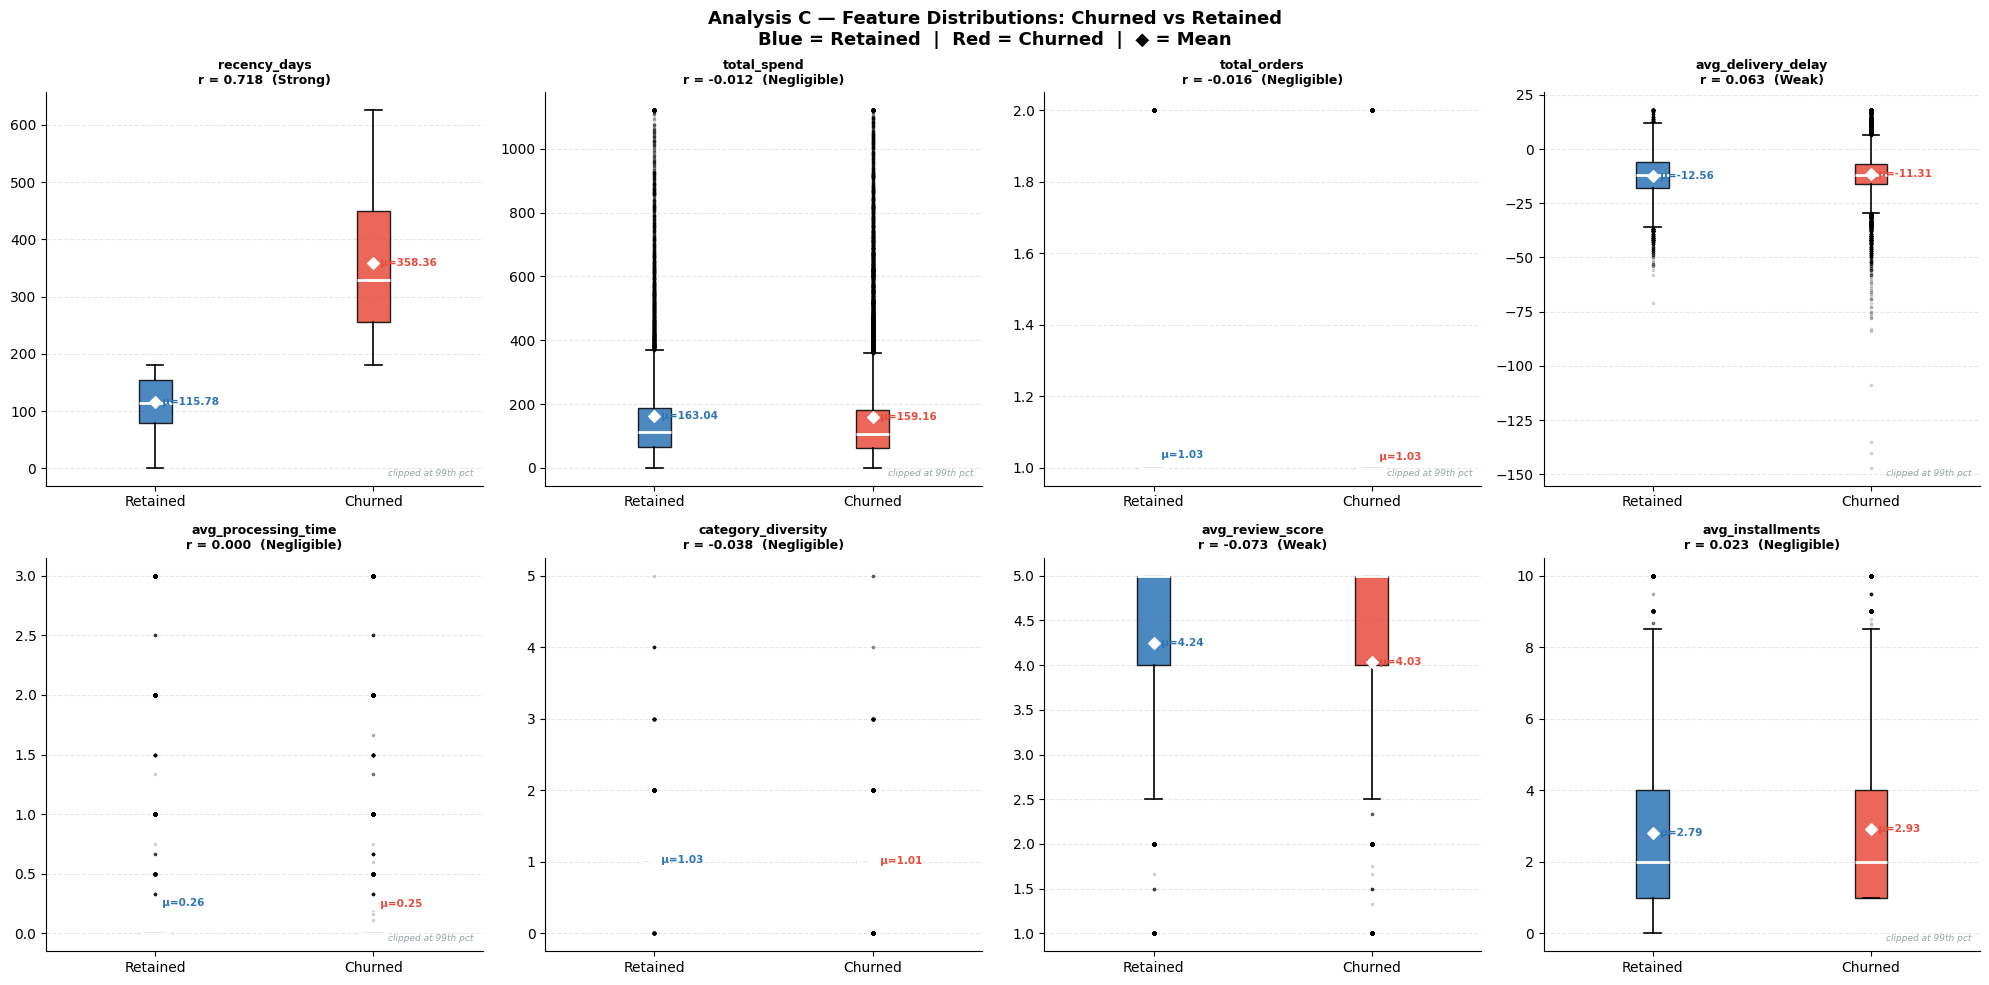

Chart saved.


In [58]:
churned_mask  = features_df['churned'] == 1
retained_mask = features_df['churned'] == 0
 
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
 
clip_percentiles = {
    'recency_days':       99,
    'total_spend':        99,
    'total_orders':       99,
    'avg_delivery_delay': 99,
    'avg_processing_time':99,
    'category_diversity': 100,
    'avg_review_score':   100,
    'avg_installments':   99,
}
 
for idx, col in enumerate(feature_cols):
    ax = axes[idx]
 
    clip_pct = clip_percentiles.get(col, 99)
    clip_val = features_df[col].quantile(clip_pct / 100)
 
    churned_vals  = features_df.loc[churned_mask,  col].clip(upper=clip_val)
    retained_vals = features_df.loc[retained_mask, col].clip(upper=clip_val)
 
    bp = ax.boxplot(
        [retained_vals.dropna(), churned_vals.dropna()],
        labels=['Retained', 'Churned'],
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2),
        flierprops=dict(marker='o', markersize=1.5, alpha=0.2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2)
    )
 
    bp['boxes'][0].set_facecolor(COLOUR_ACCENT)
    bp['boxes'][1].set_facecolor(COLOUR_HIGHLIGHT)
    for patch in bp['boxes']:
        patch.set_alpha(0.85)
 
    # Mean markers
    ax.scatter(
        [1, 2],
        [retained_vals.mean(), churned_vals.mean()],
        marker='D', color='white', s=35, zorder=5
    )
 
    # Mean labels
    ax.text(1, retained_vals.mean(),
            f'  μ={retained_vals.mean():.2f}',
            va='center', fontsize=7.5,
            color=COLOUR_ACCENT, fontweight='bold')
    ax.text(2, churned_vals.mean(),
            f'  μ={churned_vals.mean():.2f}',
            va='center', fontsize=7.5,
            color=COLOUR_HIGHLIGHT, fontweight='bold')
 
    # Get correlation for this feature
    r_val = float(corr_df.loc[col, 'correlation'])
    abr   = float(corr_df.loc[col, 'abs_correlation'])
 
    if abr >= 0.3:
        strength_label = "Strong"
    elif abr >= 0.1:
        strength_label = "Moderate"
    elif abr >= 0.05:
        strength_label = "Weak"
    else:
        strength_label = "Negligible"
 
    ax.set_title(
        f'{col}\nr = {r_val:.3f}  ({strength_label})',
        fontweight='bold',
        fontsize=9
    )
    ax.grid(axis='y', alpha=0.3, linestyle='--')
 
    if clip_pct < 100:
        ax.text(
            0.98, 0.02,
            f'clipped at {clip_pct}th pct',
            transform=ax.transAxes,
            ha='right', va='bottom',
            fontsize=6.5, color=COLOUR_NEUTRAL, style='italic'
        )
 
plt.suptitle(
    'Analysis C — Feature Distributions: Churned vs Retained\n'
    'Blue = Retained  |  Red = Churned  |  ◆ = Mean',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../outputs/figures/churn_C_feature_distributions.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

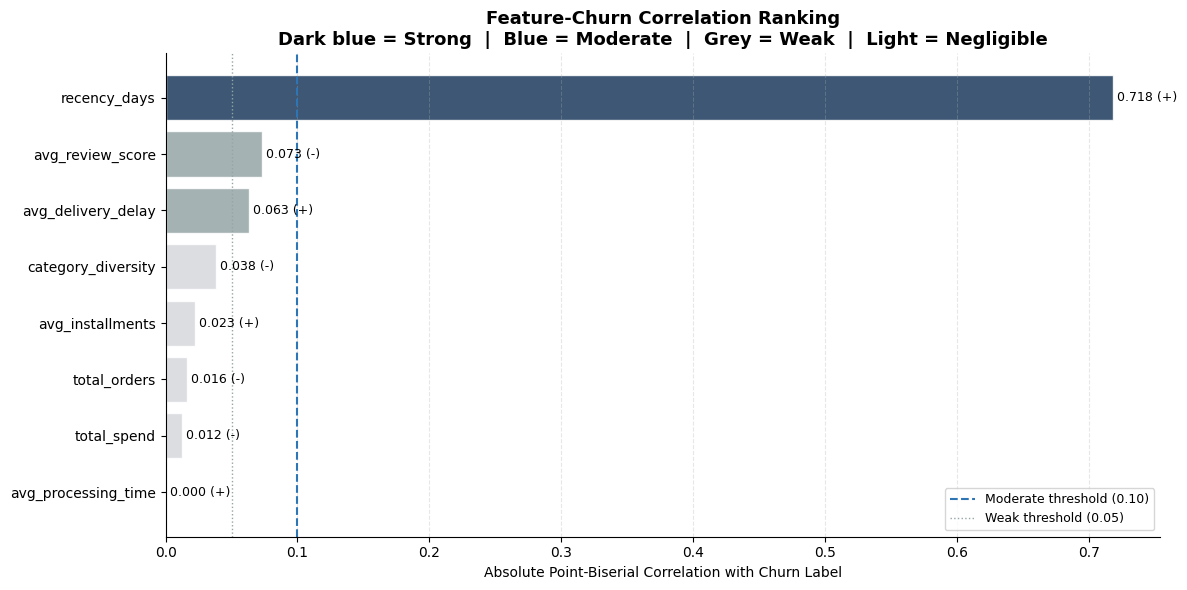

Chart saved.


In [59]:
fig, ax = plt.subplots(figsize=(12, 6))
 
sorted_corr = corr_df.sort_values('abs_correlation', ascending=True)
 
colours = []
for abr in sorted_corr['abs_correlation'].astype(float):
    if abr >= 0.3:
        colours.append(COLOUR_PRIMARY)
    elif abr >= 0.1:
        colours.append(COLOUR_ACCENT)
    elif abr >= 0.05:
        colours.append(COLOUR_NEUTRAL)
    else:
        colours.append('#D5D8DC')
 
bars = ax.barh(
    range(len(sorted_corr)),
    sorted_corr['abs_correlation'].astype(float),
    color=colours,
    alpha=0.85,
    edgecolor='white'
)
 
# Value labels
for bar, (feat, row) in zip(bars, sorted_corr.iterrows()):
    r_val  = float(row['correlation'])
    abr    = float(row['abs_correlation'])
    direct = '(+)' if r_val > 0 else '(-)'
    ax.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height()/2,
        f'{abr:.3f} {direct}',
        va='center', fontsize=9
    )
 
# Threshold lines
ax.axvline(x=0.10, color=COLOUR_ACCENT, linewidth=1.5,
           linestyle='--', label='Moderate threshold (0.10)')
ax.axvline(x=0.05, color=COLOUR_NEUTRAL, linewidth=1,
           linestyle=':', label='Weak threshold (0.05)')
 
ax.set_yticks(range(len(sorted_corr)))
ax.set_yticklabels(sorted_corr.index, fontsize=10)
ax.set_xlabel('Absolute Point-Biserial Correlation with Churn Label')
ax.set_title(
    'Feature-Churn Correlation Ranking\n'
    'Dark blue = Strong  |  Blue = Moderate  |  '
    'Grey = Weak  |  Light = Negligible',
    fontweight='bold'
)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3, linestyle='--')
 
plt.tight_layout()
plt.savefig(
    '../outputs/figures/churn_C_feature_correlations.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")
 

In [60]:
churn_features = features_df[[
    'customer_unique_id',
    # RFM components
    'recency_days',
    'total_orders',
    'total_spend',
    # Engineered features
    'avg_delivery_delay',
    'avg_processing_time',
    'category_diversity',
    'avg_review_score',
    'avg_installments',
    # Target variable
    'churned'
]].copy()
 
# Final null check
print("Final feature dataset:")
print(f"  Shape: {churn_features.shape}")
print(f"  Nulls: {churn_features.isnull().sum().sum()} total")
print(f"  Churn rate: {churn_features['churned'].mean()*100:.1f}%")
print(f"\nFeature summary:")
print(churn_features.drop(columns=['customer_unique_id', 'churned']).describe().round(2))
 
churn_features.to_csv(
    '../data/processed/churn_features.csv',
    index=False
)
print("\nchurn_features.csv saved — ready for Notebook 03")
 

Final feature dataset:
  Shape: (96136, 10)
  Nulls: 0 total
  Churn rate: 71.1%

Feature summary:
       recency_days  total_orders  total_spend  avg_delivery_delay  \
count      96136.00      96136.00     96136.00            96136.00   
mean         288.78          1.03       166.52              -11.51   
std          153.43          0.21       231.36               10.18   
min            1.00          1.00         0.00             -147.00   
25%          164.00          1.00        63.12              -17.00   
50%          269.00          1.00       108.00              -12.00   
75%          398.00          1.00       183.40               -7.00   
max          773.00         17.00     13664.08              188.00   

       avg_processing_time  category_diversity  avg_review_score  \
count             96136.00            96136.00          96136.00   
mean                  0.27                1.02              4.09   
std                   0.99                0.19              1.34  

### Analysis C — Feature-Churn Relationships: Findings

---

**Correlation results:**

| Feature | r | Strength | Note |
|---------|---|----------|------|
| recency_days | +0.720 | Strong | Structural  see below |
| avg_review_score | −0.070 | Weak | Modest signal |
| avg_delivery_delay | +0.060 | Weak | Modest signal |
| category_diversity | −0.040 | Negligible | As predicted |
| avg_installments | +0.020 | Negligible | No signal |
| total_orders | −0.020 | Negligible | As predicted |
| total_spend | −0.010 | Negligible | Counterintuitive  see below |
| avg_processing_time | +0.000 | Negligible | No signal |

---

**The structural leakage finding:**
recency_days has a 0.720 correlation with the churn label
because the churn label was defined using a recency threshold
(180 days). These two variables share a definitional
relationship — they are measuring the same underlying
concept from two angles. This is target leakage.

Including recency_days produces a high-performing model but
one that is primarily a recency classifier rather than a
true behavioural churn predictor. This limitation is
acknowledged and documented. In a production setting the
model would need to be retrained with forward-looking
features rather than backward-looking recency.

---

**The counterintuitive spend finding:**
total_spend has near-zero correlation (−0.01) with churn
despite Hypothesis 2 showing a large spend difference
between high and low RFM customers (R$300 vs R$81).

This apparent contradiction resolves when you understand
the mediation structure: spend differences between RFM
segments are entirely driven by recency. A high-spending
customer who last ordered 400 days ago is churned. A
low-spending customer who last ordered 30 days ago is
retained. When recency is held constant, spending level
adds no additional predictive power for churn.

**In plain English: it does not matter how much you
spent when you spent it is all that matters.**

---

**Predictions from Hypothesis 2 confirmed:**
Hypothesis 2 predicted orders and category diversity
would be weak predictors. Both show negligible correlation
(−0.02 and −0.04 respectively). The prediction was correct.

---

**Decision for Notebook 03:**
recency_days is retained as a feature with the leakage
limitation explicitly documented. The model will achieve
high ROC-AUC primarily through recency. Secondary features
(avg_review_score, avg_delivery_delay) add modest signal.
SHAP analysis will quantify exactly how much each feature
contributes beyond recency.

---

**Notebook 02 complete.**
churn_features.csv saved: 96,136 customers × 8 features + 1 label.

Analytical chain summary:
- H1: delivery delay hurts satisfaction ✓ validated
- H2: RFM segments differ primarily on spend ✓ validated
- Analysis A: 71.1% churn rate, 2.5:1 imbalance ✓ documented
- Analysis B: 71.7pp churn spread across segments (V=0.57) ✓
- Analysis C: recency dominates, structural leakage identified ✓

Every modelling decision in Notebook 03 is now motivated
by evidence from Notebook 02.